# 0. Page de garde

**Nom Prénom** : ALBURQUERQUE Julien  
**Formation** : CISIA — Concevoir et implémenter une solution d'intelligence artificielle (référentiel C1→C9)  
**Cas d'usage** : Détection précoce du décrochage étudiant en L1  
**Dépôt GitHub** : [cisia-decrochage-etudiant](https://github.com/jalb-code/cisia-decrochage-etudiant.git)  
**Date de soutenance** : 2026-09-01 — **Version du notebook** : v0.3 (2026-08-16) 

In [1]:
import hashlib
import json
import logging
import shutil
import warnings

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython.display import Markdown, display
from sklearn.model_selection import GridSearchCV

from decrochage_l1 import eda
from decrochage_l1.config import settings
from decrochage_l1.data import preparation
from decrochage_l1.data.utils import cleaning_utils, profiling_utils
from decrochage_l1.modeling import (
    ablation,
    evaluation,
    families,
    preprocessing,
    protocol,
    threshold,
    tuning,
)
from decrochage_l1.serving import normalization, schemas, scoring, store
from decrochage_l1.serving.contract import ModelFacts, OperationalDefaults, ServiceContract
from decrochage_l1.serving.store import EntrepotModele

# Silences d'import : progress-bar tqdm (ipywidgets absent en exécution notebook) et
# journal verbeux de codecarbon - on garde les vraies erreurs, on coupe le bruit.
warnings.filterwarnings("ignore", message=".*IProgress.*")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 240)
pd.set_option("display.max_colwidth", 38)

# Enregistrer les paliers bronze/silver/gold en CSV sur disque. Par défaut False : le
# notebook calcule tout en mémoire, sans rien écrire (les paliers se rejouent à la demande).
ENREGISTRER_PALIERS = True

# §8+ : reprendre en mémoire le gold construit en §7 (False) ou le relire depuis
# data/gold/ (True), pour exécuter la modélisation indépendamment des sections amont.
CHARGER_GOLD_DEPUIS_CSV = False

# §9 : recharger les réglages Optuna depuis le cache (True) ou les relancer
# (False, write-through). Optuna étant seedé, le recalcul rend les mêmes paramètres.
REGLAGE_DEPUIS_CACHE = True
CACHE_REGLAGE = settings.report_dir / "tuning_cache.json"

## _Scaffolding du projet_

- **Création de la structure du projet** : Le code réutilisable dans `src/`, notebook unique `JALB-Decrochage-l1.ipynb` , données dans `data` non commité (voir journal de bord)
- **Hygiène de code** : format/lint (`ruff`), tests (`pytest`), `pre-commit` et intégration continue (GitHub Actions) → un livrable reproductible et vérifiable.

### _Journal de bord des décisions_

1. **[D01] Ne pas versionner les données.**  
⇒ Les fichiers data contiennent des données personnelles sensibles. Rien n'atteste formellement de leur caractère synthétique donc par précaution RGPD (minimisation), je les exclus du dépôt Git. Le dépôt cloné n'est donc pas exécutable en l'état - compromis assumé, la procédure de mise en place des données étant décrite dans le `README.md`.

 
2. **[D02] Utilisation de l'IA générative**  
⇒ J'ai choisi d'utiliser Claude Code pour m'assister dans la réalisation de ce projet. Au vu du temps limité que je peux y allouer et de la méta actuelle du développement logiciel, ce serait selon moi une erreur de ne pas l'utiliser. Il n'en reste pas moins qu'il s'agit d'un projet de certification où je dois démontrer mes compétences. C'est pourquoi j'ai décidé d'encadrer l'usage de l'IA de la manière suivante :
   - l'outil code selon mes directives et sous ma relecture ;
   - c'est moi qui prends les décisions, en m'appuyant sur des agents consultants pour m'éclairer avant de trancher (consultant ML, consultant RGPD, gardien du cas d'usage) ;
   - dans le notebook, les cellules de code sont écrites par l'IA sous mes directives ; les cellules markdown sont d'abord rédigées par moi, puis relues et corrigées par l'IA, avant une dernière relecture de validation de ma part.

# 1. Résumé exécutif

**Problème** : Dans une université pluridisciplinaire, ~28 % des étudiants de L1 de la cohorte abandonnent (1 479 sur 5 200). Aujourd'hui, l'abandon ne se constate qu'en fin de semestre — trop tard pour agir.

**Objectifs** : Concevoir une solution d'IA capable de prédire, **à mi-S1**, le risque de décrochage, afin de proposer un accompagnement au bon moment. 2 cibles de prédictions sont demandées: 
  - **Risque d'abandon** — score de risque (classification) : faut-il proposer un accompagnement ?
  - **Moyenne finale (/20)** — régression : calibrer et prioriser l'intensité de l'accompagnement.

## Approche

Une démarche de bout en bout, du besoin métier au service qui dure ; chaque étape est développée et **justifiée dans sa section** (journal de bord).

```mermaid
flowchart TD
    A["1 · Comprendre le besoin<br/>décrochage constaté trop tard → agir à mi-S1<br/>Section §2"]
    B["2 · Cadrer avant tout<br/>cibles · RGPD, éthique, responsabilités · aide à la décision<br/>Section §2–§4"]
    C["3 · Fiabiliser la donnée<br/>profilage · conformation · EDA<br/>exclusions de principe : anti-fuite, minimisation · features<br/>Section §5–§7"]
    D["4 · Modéliser et comparer<br/>baseline + ≥2 familles → départage sur AUC<br/>classification + régression<br/>Section §8–§9"]
    E["5 · Prouver et arbitrer<br/>métriques · seuil = coût FN&gt;FP · SHAP · audit d'équité<br/>Section §9, §12"]
    F["6 · Industrialiser<br/>pipeline sérialisé (score) · architecture cible<br/>Section §10–§11"]
    G["7 · Assumer les limites et durer<br/>limites connues · suivi de dérive · ré-entraînement · versioning<br/>Section §13–§14"]
    A --> B --> C --> D --> E --> F --> G
    G -.->|nouvelle promotion / dérive| C
```

## Résultats clés

- **Détection du décrochage (`abandon`)** : les modèles sont départagés sur l'**AUC = ⟨valeur — §12⟩** (indépendante du seuil) ; au seuil retenu, le modèle retrouve **⟨rappel en % — §12⟩** des décrocheurs.
- **Priorisation (`moyenne_finale`)** : régression de la note finale (**⟨RMSE/MAE — §12⟩**, R² = ⟨valeur — §12⟩), pour calibrer l'intensité de l'accompagnement.
- **Décision métier** : seuil fixé par l'**asymétrie des coûts** (un décrochage manqué coûte plus qu'un signalement à tort) : **⟨N — §12⟩** étudiants signalés, dont **⟨M — §12⟩** décrocheurs réels (précision ⟨% — §12⟩).
- **Explicabilité** : restitution **globale et locale** (SHAP)
- **Industrialisation** :  pipeline sérialisé + contrat `predict()`, architecture cible et suivi de dérive.

## Limites

- **Généralisation et dérive** : une seule cohorte (2024-2025, données synthétiques) et une validation intra-cohorte ⇒ le modèle est susceptible de devoir être **ré-entraîné** à la prochaine promotion.
- **Complétude des données** : manquants sur 10 colonnes ⇒ Mise en place de stratégie d'imputation comme parade à cette limite
- **Calibrage du seuil** : coûts métier (FN/FP) et capacité d'accompagnement non fournis ⇒ hypothèse de travail : un décrochage manqué (FN) pèse plus qu'un signalement à tort (FP), sans que ce dernier soit anodin.
- **Déployabilité conditionnée** : la mise en production dépend d'actes du responsable de traitement (AIPD, base légale confirmée par le DPO, information des étudiants) et d'effets de bord du marquage à documenter

*TODO — à compléter après §12 : cohorte unique et synthétique ; seuil à recalibrer par promotion.*

# 2. Cadrage métier et cas d'usage — journal de bord [C1]

## Problématique métier

Une université pluridisciplinaire constate un **taux d'abandon élevé en L1**. Aujourd'hui,
l'abandon se **constate en fin de semestre** - trop tard pour agir.

La **direction de la réussite étudiante** veut identifier, **dès mi-parcours du S1**, les
étudiants à risque de décrochage, pour déclencher un accompagnement - tutorat, soutien
méthodologique, aide sociale.

## Enjeux métier

- **Humain** - un décrochage laisse une trace **psychologique** (sentiment d'échec, perte de
  confiance, déclassement ressenti) et **professionnelle** (employabilité réduite, entrée
  retardée dans la vie active). Il est souvent **réversible s'il est repéré tôt**.
- **Institutionnel** - les ressources d'accompagnement sont **limitées** (heures de tutorat,
  aides) ⇒ il faut **cibler**. D'où le rôle de la cible secondaire `moyenne_finale` - prioriser
  et calibrer l'intensité - et de l'explicabilité - désigner les **facteurs** sur lesquels agir.
- **Économique** - un abandon est un investissement gaspillé et se répercute en cascade :
  - **l'étudiant** perd l'année engagée et s'expose au chômage ou à un emploi moins rémunérateur ;
  - **l'institution** perd les moyens publics investis pour le former ;
  - **la société** compte un diplômé de moins - productivité et recettes fiscales moindres.

## Objectifs et contraintes

Deux prédictions complémentaires à mi-S1 :

| Cible | Variable | Tâche | Rôle |
|---|---|---|---|
| **Principale** | `abandon` (0/1) | Classification binaire | Faut-il proposer un accompagnement ? |
| **Secondaire** | `moyenne_finale` (/20) | Régression | Prioriser et calibrer l'intensité |

La cible principale déclenche l'action ; la secondaire la **module**.

Trois contraintes pèsent dès le cadrage et orientent toute la chaîne :

- **Horizon mi-S1 - risque de fuite temporelle.** Une variable n'est légitime que si elle est
  **connue à mi-parcours** ; une donnée consolidée en fin de S1 (`moyenne_partiels_s1`,
  `nb_ue_validees_s1`) gonflerait la validation tout en rendant le modèle inexploitable en
  production. Reste à établir en **§3** quelles variables sont disponibles à mi-S1.
- **Explicabilité exigée - restitution SHAP.** L'énoncé impose des indicateurs **explicables** ;
  la solution prévoit une restitution **globale et locale** (SHAP) - voir journal de bord.
- **Éthique et RGPD - variables sensibles.** L'énoncé exige un usage **éthique et conforme** des
  données étudiantes ; biais portés par `sexe`, `boursier`, `etablissement_origine`. Cet aspect sera traité en **§4**.

## Rythme d'usage : une campagne par an

Le scoring s'exécute **une fois par an**, à mi-S1, sur **toute la promotion** en cours - il n'y a **pas de besoin temps réel**. Ce que ce rythme implique pour le contrat de service et le choix du modèle est tranché au journal de bord.

## Le coût d'une erreur : FN (décrochage manqué) >> FP (signalement à tort)

Le modèle peut se tromper de **deux façons**, qui n'ont ni les mêmes conséquences ni le même coût :

- **Faux négatif (FN) - un décrochage manqué.** Le modèle prédit « pas d'abandon » pour un
  étudiant qui décroche : aucun accompagnement n'est proposé à qui en aurait eu besoin, l'occasion
  d'agir à temps est perdue. **Coût le plus lourd, et souvent irréversible** - une chance de
  réussite qui ne revient pas pour l'étudiant, une année d'investissement perdue pour l'institution.
- **Faux positif (FP) - un signalement à tort.** Le modèle prédit « à risque » pour un étudiant
  qui ne décroche pas : une ressource limitée est mobilisée pour rien. **Coût borné et
  réversible** - un créneau de tutorat consommé en trop ; s'y ajoute, pour l'étudiant, une
  étiquette « à risque » qui n'est pas neutre.

**FN >> FP** : un étudiant perdu pèse plus qu'un créneau de tutorat dépensé. La solution doit donc privilégier le rappel (*recall*) sur `abandon` - mieux vaut un signalement à tort qu'un décrochage manqué. Sans pour autant tout signaler : les FP consomment la capacité d'accompagnement, limitée. Où placer le curseur, c'est le seuil - arbitré en §9 (son effet mesuré sur le test en §12).

## Parties prenantes

| Acteur | Rôle | Ce qu'on doit lui fournir |
|---|---|---|
| **Direction réussite étudiante** | Commanditaire | Une solution répondant aux objectifs qu'elle a définis. |
| **Tuteurs / responsables pédagogiques** | Utilisateurs | Un outil qui, à mi-S1, signale le risque, estime la moyenne finale et **explique** la prédiction, pour adapter l'accompagnement. |
| **Étudiant** | Sujet des données **et** bénéficiaire | Minimisation des données ; vigilance sur biais et stigmatisation |
| **DPO / référent éthique** | Garant de la conformité | Les livrables de conformité |
| **SI scolarité / LMS** | Fournisseur des données | Une proposition d'intégration technique |

## _Journal de bord des décisions_

1. **[D03·D04] FN ≫ FP, sans coût métier facilement chiffrable**  
⇒ Je départage les modèles sur la **ROC/AUC** - indépendante du seuil et fiable à déséquilibre modéré (~28/72) - **complétée par la PR-AUC**, qui rend compte de la performance sur la classe minoritaire (les décrocheurs) que la ROC/AUC lisse.  
⇒ Je fixe le point de fonctionnement en §9, sur les probabilités out-of-fold du train : faute de coût métier chiffrable, aucun seuil ne se déduit par le calcul - il se **déclare** par une politique lisible et **configurable**, par défaut un **plancher de rappel** (détecter au moins R % des décrocheurs), à défaut une **capacité d'accompagnement** ; le seuil reste externe au modèle (D15). §12 n'en mesure que l'effet sur le test scellé - le choisir sur le test reviendrait à l'y ajuster puis à l'y juger.

2. **[D05] Explicabilité imposée par l'énoncé**  
⇒ Je fournis une explicabilité globale et locale (SHAP) et j'en fais un critère de choix du modèle : le besoin des équipes pédagogiques est double - **global** (quels facteurs pèsent sur le risque) et **local** (pourquoi *cet* étudiant est signalé, pour adapter l'accompagnement).

3. **[D06] Usage : une campagne par an, sur toute la promotion**  
⇒ Je prévois d'intégrer dans la solution finale un point d'entrée qui score une promotion entière en une passe (endpoint /predict-cohorte);

# 3. Données : disponibilité, gouvernance et alternatives — journal de bord [C1]

## 3.1 Description des sources

Deux fichiers CSV sont fournis :

- **`decrochage_etudiants_complet_V5.csv`** - le jeu principal : ~5 200 lignes, 33 colonnes, une ligne par étudiant de L1, **une seule cohorte 2024-2025**, observée à mi-parcours du S1. Un échantillon de 50 lignes accompagne le fichier pour une première lecture.
- **`catalogue_formations_V5.csv`** - table de référence des filières, jointe au jeu principal par `filiere`.

L'ensemble des colonnes peut être classées par thème métier :

| Thème | Colonnes |
|---|---|
| Identifiants | `student_id`, `id_dossier` |
| Contexte d'inscription | `annee_universitaire`, `filiere`, `date_inscription` |
| Profil social et démographique | `age`, `sexe`, `boursier`, `distance_domicile_km`, `heures_travail_remunere_sem` |
| Parcours antérieur | `bac_type`, `mention_bac`, `etablissement_origine` |
| Engagement LMS | `connexions_lms_30j`, `heures_lms_total`, `ressources_consultees`, `messages_forum` |
| Assiduité et travail rendu | `taux_presence_pct`, `retards_rendus`, `nb_devoirs_total`, `nb_devoirs_rendus` |
| Résultats académiques | `moyenne_partiels_s1`, `nb_ue_total`, `nb_ue_validees_s1` |
| Ressenti déclaré | `motivation`, `satisfaction`, `sentiment_appartenance` |
| Avis du tuteur | `commentaire_tuteur` |
| Leurres annoncés | `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` |
| Cibles | `abandon`, `moyenne_finale` |
| Information filière | Dans le 2nd fichier : `faculte`, `niveau`, `ects_semestre`, `capacite_accueil`, `volume_horaire_s1`, `taux_reussite_historique_pct` |

 ## 3.2 Disponibilité, accès et gouvernance

**Disponibilité et accès**

L'énoncé ne documente pas comment ces données sont collectées. Au vu de la nature des colonnes (traces LMS, dossier de scolarité, état civil, enquêtes déclaratives), je pose l'hypothèse d'un jeu assemblé automatiquement par l'université depuis ses outils (LMS, inscription…).

**Gouvernance, à notre niveau**

Les données ne servent qu'à l'entraînement et à l'évaluation des modèles. Elles ne sont pas conservées au-delà de la période de VSR (vérification de service régulier) qui suit la mise en production - ni archivage, ni réutilisation à d'autres fins. Corollaire : tout ré-entraînement (§13) suppose que l'université remette à disposition un jeu de données à jour - nous n'en gardons aucune copie dormante. La conformité RGPD d'ensemble (base légale, finalité, information des personnes) est traitée en §4 ; le stockage des paliers en §7.

## 3.3 Données connues à mi-S1 et fuite temporelle

Une variable n'est exploitable que si sa valeur **existe à mi-parcours** : en utiliser une qui n'est
connue que plus tard ferait reposer le modèle sur une information absente au moment du scoring - la
validation paraîtrait flatteuse, mais le modèle serait inexploitable en production.

**Cas des colonnes `moyenne_partiels_s1` et `nb_ue_validees_s1`**

Résultats consolidés en fin de S1 : les intégrer comme features à mi-S1 serait une fuite
temporelle. Je les place hors du périmètre de scoring.

**Cas de la colonne `commentaire_tuteur`**

Les libellés relevés sont des bilans de semestre (« bon semestre », « résultats fragiles aux
partiels ») - or les partiels tombent en fin de semestre. Je présume donc un champ **rédigé en fin
de S1**, hors horizon, que je place hors périmètre au même titre que les deux colonnes ci-dessus.
La présomption s'appuie aussi sur un fort volume d'absence.

**Cas des cibles `abandon` et `moyenne_finale`**

Ce sont les cibles de prédiction, constatées en fin de S1 : inconnues à mi-S1 par nature.

**Cas des autres colonnes**

Aucune information ne laisse penser qu'elles ne soient pas connues à mi-S1 : je les présume disponibles à mi-parcours - présomption, non preuve (D18).

## 3.4 Stratégie d'imputation des valeurs manquantes

Le constat chiffré - colonnes concernées et taux - est établi en §5, le diagnostic mené
en §6 ; ici je fixe seulement la **méthode de décision**, pas son résultat - une imputation
se décide après la mesure qui la fonde.

Un mécanisme d'absence ne s'observe pas : je ne cherche pas à le *prouver*, mais à répondre à
trois questions dont chaque réponse commande la suite.

**Q1 - Les trous se concentrent-ils sur les mêmes dossiers ?** (structure, §6)
Si une poignée de dossiers portent l'essentiel des absences, leur suppression *peut* être
envisagée - à la double condition que la perte soit négligeable et l'absence plausiblement
aléatoire. Hors ce cas, je n'élimine aucune ligne : supprimer biaise dès que l'absence n'est
pas MCAR et sacrifie des décrocheurs (classe rare). C'est le défaut, pas la règle.

**Q2 - L'absence est-elle un signal ?** (lien avec `abandon`, §6)
Si manquer va de pair avec l'issue, j'ajoute un indicateur binaire `x_manquant` *avant*
d'imputer, pour conserver ce que le trou porte. Sinon, l'imputation seule suffit.

**Q3 - L'absence est-elle présumée liée à la valeur cachée ?** (hypothèse métier, MNAR)
Présomption, non testable. Si je la retiens, la valeur d'imputation relève alors du
**métier**, pas de la statistique : une modalité déclarée « aucune »/« Inconnu » (cat.), un
plancher métier tel que `0` pour une non-déclaration (num.).

À défaut, quand aucune des trois ne tranche : **médiane** (num.) / **mode** (cat.), sans indicateur.

**Anti-fuite** : imputation et indicateurs sont `fit` sur le **train seul**, dans le `Pipeline` (§8).

## 3.5 Enrichissement : catalogue, cohorte, ré-échantillonnage

**Catalogue des filières**

Toutes ses colonnes - faculté, niveau, ECTS, capacité, volume horaire, taux de réussite historique - sont des attributs de la filière : à filière donnée, leur valeur est fixe. Ce sont donc des fonctions déterministes de filiere, déjà présente dans le jeu étudiant - les joindre n'introduit aucune information nouvelle, seulement une réécriture de filiere.

**Une seule cohorte** 

Le jeu ne couvre que 2024-2025. Le modèle risque d'être spécifique à cette
promotion et de dériver aux suivantes - d'où la nécessité d'un ré-entraînement sur plusieurs
années et d'un suivi de dérive (§13). Limite à documenter et surveiller, pas à corriger ici.

**Déséquilibre de classes** 

Le taux d'abandon annoncé (~28 %) est un déséquilibre modéré : il ne justifie pas un ré-échantillonnage (SMOTE), qui fabriquerait des exemples synthétiques pour un gain douteux. Une pondération des classes (class_weight) suffit si besoin. Le taux exact sera confirmé en §6 - seule mesure susceptible de rouvrir la question.

## 3.6 Les leurres annoncés

L'énoncé désigne trois leurres : `groupe_td`, `couleur_carte_etudiante`, `jour_inscription`. Aucun
n'a de lien causal plausible avec le décrochage, et `jour_inscription` paraît n'être que le jour de
semaine de `date_inscription`. Je ne les exclus pas pour autant : je les **conserve dans le gold** et
je démontre leur nullité, plutôt que de la supposer, par trois contrôles convergents.

- **Redondance** - `jour_inscription` reproduit-il le jour de semaine de `date_inscription` ? (§6)
- **Lien bivarié** - chaque leurre est-il associé à `abandon`, seul à seul ? (§6)
- **Poids multivarié** - une fois dans le modèle, pèsent-ils ? SHAP ≈ 0 attendu (§12)

## _Journal de bord des décisions_

1. **[D07] `commentaire_tuteur` hors périmètre de scoring**  
⇒ Présumé rédigé en fin de S1 (contenu de bilan + ~49 % de vides) : l'employer à mi-S1 serait une fuite temporelle.

1. **[D08] Pas d'enrichissement avec le catalogue de formation**  
⇒ Toutes ses colonnes sont des fonctions déterministes de filiere, déjà présente : les joindre n'ajoute aucune information, seulement une réécriture.

1. **[D09] Valeurs manquantes : trois questions avant d'imputer**  
⇒ (1) trous concentrés sur les mêmes dossiers → (2) absence corrélée à `abandon` → (3) absence présumée liée à la valeur cachée (MNAR) - chaque réponse commande le traitement (suppression au cas limite, indicateur `x_manquant`, valeur déclarée) ; à défaut médiane/mode. Diagnostic en §6, imputation ajustée sur le train seul (§8). *Écarté* : la suppression **systématique** des lignes incomplètes - elle biaise dès que l'absence n'est pas MCAR et sacrifie des décrocheurs (classe rare).

1. **[D10] Pas de ré-échantillonnage (SMOTE)**  
⇒ Le déséquilibre annoncé (~28 %) est modéré et ne le justifie pas ; une pondération des classes suffit si nécessaire. Le taux sera confirmé en §6 - seule mesure susceptible de rouvrir la question.

1. **[D11] Leurres : conservés et démontrés nuls, plutôt qu'exclus a priori**  
⇒ Je les garde dans le gold et démontre leur nullité plutôt que la supposer : redondance et lien bivarié (EDA, §6), coût de retrait mesuré par ablation (§8), confirmé par SHAP (§12). Écarté - les exclure a priori sur « aucun sens métier », jugement contestable qui prive de la preuve sans rien économiser.

1. **[D18] Les colonnes hors résultats fin-de-S1 sont présumées connues à mi-S1**  
⇒ Faute de documentation sur l'horizon de collecte, je présume disponibles à mi-parcours toutes les colonnes hors résultats consolidés (D07) et cibles - c'est une **présomption raisonnée, pas une preuve**. En production, le contrat d'entrée fige cet horizon. *Écarté* - inclure une variable au statut temporel douteux : gain de validation qui ne se retrouverait pas en production (fuite).


# 4. Enjeux éthiques, sociétaux et conformité — journal de bord [C2]

## 4.1 Base légale et finalité

Le traitement doit reposer sur une base légale avant toute autre considération. Je retiens la **mission d'intérêt public** (art. 6.1.e) : l'aide à la réussite étudiante relève des missions de service public de l'établissement. Cette base **dispense du consentement** - l'accompagnement ne saurait être conditionné à un accord préalable, ni laisser un étudiant renoncer à une aide. Elle suppose un rattachement à une base en droit national (art. 6.3) et doit être **confirmée par le DPO**. Elle a un mérite second : elle évite le point dur du consentement pour les étudiants mineurs, qu'une cohorte de L1 peut compter.

La **finalité est déterminée** (art. 5.1.b) : proposer un **accompagnement pédagogique**. Tout autre usage est proscrit et consigné dans la fiche du modèle - sélection à l'entrée, réorientation subie, évaluation des enseignants. La cible secondaire `moyenne_finale` relève du même cadre : une aide à la décision d'accompagnement, **jamais** une note anticipée ni un instrument d'évaluation.

## 4.2 Minimisation et données identifiantes

Le principe de **minimisation** (art. 5.1.c) commande de ne traiter que les données **nécessaires à la finalité** : le seul pouvoir prédictif d'une variable ne suffit pas à la justifier. Il gouverne les exclusions de ce chapitre (§4.4) et le sort des variables démontrées inutiles (D16).

Les identifiants `student_id` et `id_dossier` **n'entrent pas dans le modèle** : ils identifient un dossier, ils ne portent aucune information généralisable. Le contrat d'API pourra accepter un identifiant, mais **au seul titre de la corrélation** entre une requête et sa réponse, à l'usage de l'appelant ; la solution ne le **journalise ni ne le conserve**. Les modalités de conservation côté établissement relèvent de sa responsabilité (§4.7).

## 4.3 Décision automatisée et droit à l'explication

Le système ne prend **aucune décision** au sens de l'art. 22 : il produit une **probabilité de décrochage**, et l'équipe pédagogique décide de l'accompagnement (garde-fous en §4.6). L'humain n'est pas une validation de façade - c'est lui qui arbitre, la probabilité n'étant qu'un signal parmi d'autres.

Le **droit à l'explication** est servi par l'explicabilité du modèle : pour chaque étudiant signalé, la **contribution de ses variables** (SHAP, local et global) est restituée. Ce droit se rattache aux **art. 13-14** (information sur la logique sous-jacente), non à l'art. 15 qui vise l'accès de la personne à ses propres données. L'explicabilité est déjà actée comme critère de choix du modèle (D05, §2) et démontrée en §12.

## 4.4 Variables protégées et proxies socio-économiques

Le jeu porte deux **caractéristiques protégées au sens du droit de la non-discrimination** - le `sexe` et le statut `boursier` - non des données sensibles de l'art. 9 RGPD, qui ne couvre ni l'un ni l'autre. L'**art. 225-1 du Code pénal** interdit de distinguer les personnes sur le fondement du sexe et de la « particulière vulnérabilité résultant de la situation économique », à laquelle le statut boursier se rattache.

Je les **exclus du modèle par principe** - de non-discrimination et de minimisation - **quel que soit leur pouvoir prédictif** (D13). Elles ne disparaissent pas du jeu pour autant : conservées **hors modèle**, elles servent l'**audit d'équité** par sous-groupes (§12), qui vérifie que le modèle ne rate pas davantage de décrocheurs selon le sexe ou le statut boursier.

Trois variables ne sont pas protégées mais appellent un contrôle : `etablissement_origine`, `heures_travail_remunere_sem`, `distance_domicile_km`. On peut soupçonner qu'elles laissent **déduire la situation économique** de l'étudiant - la même information que porte `boursier`, exclu ci-dessus. Les intégrer sans vérification risquerait de **ré-encoder** cette variable protégée écartée (discrimination indirecte). Je conditionne donc leur entrée dans le modèle à l'**absence de corrélation avec `boursier`** - contrôle reporté à l'EDA (§6, D14).

## 4.5 Biais de représentation

Un modèle apprend mal ce que les données représentent peu. Outre le biais de *décision* (§4.6), il faut surveiller le biais de *représentation* : une modalité rare - le `sexe` renseigné « Autre », un type d'établissement marginal - risque d'être mal apprise, et le modèle peu fiable sur le groupe correspondant. Le repérage de ces modalités est reporté à l'EDA (§6) ; selon le résultat, une modalité insuffisamment représentée est soit **regroupée** (modalité « Autre » déclarée), soit **signalée comme zone de moindre fiabilité** ; dans les deux cas, l'**audit d'équité** couvre ces modalités rares (§12, D17), pour vérifier que la performance ne s'effondre pas sur ces groupes peu représentés.

## 4.6 Marquage, stigmatisation et garde-fous

Signaler un étudiant n'est pas neutre. **Ne pas signaler** le laisse sans proposition d'aide - le risque même que le projet entend réduire. **Signaler** ouvre deux risques opposés : la **prophétie auto-réalisatrice** - un étudiant désigné « à risque » peut intérioriser ce jugement - et la **stigmatisation** si l'information circule au-delà de ceux qui accompagnent. Aucun n'est nul ; les garde-fous visent à les contenir.

**Côté établissement**

- la probabilité n'est **jamais** le seul critère de déclenchement ; la décision revient à l'**équipe pluridisciplinaire** ;
- l'étudiant peut **refuser** un accompagnement, et peut en **demander** un même à probabilité faible - c'est l'équipe qui statue ;
- il incombe à l'établissement de **s'assurer que ces garde-fous sont effectifs**, et pas seulement affichés.

**Côté solution**

- exposer une **probabilité**, non une étiquette `abandon` Oui/Non ; l'étiquette sert au réglage du seuil (§9) mais reste **masquée en production**, pour ne pas « marquer » l'étudiant (D15).

## 4.7 Ce qui relève du responsable de traitement

L'établissement est **responsable de traitement** ; la solution agit comme **sous-traitant** (art. 28). Les points suivants sont cadrés ici mais **produits par l'établissement**, hors périmètre du notebook :

- **information des personnes** (art. 13-14) - informer les étudiants de l'existence du traitement et de sa logique ;
- **conservation** (art. 5.1.e) - durée limitée à ce que la finalité exige ; cohérent avec §3.2, aucune copie dormante côté solution ;
- **sécurité** (art. 32) - mesures techniques et organisationnelles de protection des données ;
- **analyse d'impact** (AIPD, art. 35) - le profilage d'un public étudiant en fait un traitement candidat.

## _Journal de bord des décisions_

1. **[D12] Base légale = mission d'intérêt public (art. 6.1.e)**  
⇒ Je fonde le traitement sur la mission de service public d'aide à la réussite, ce qui dispense du consentement ; à confirmer par le DPO et à rattacher à une base en droit national. *Écarté* - le consentement (art. 6.1.a) : il conditionnerait l'accompagnement à un accord préalable et laisserait un étudiant renoncer à une aide, à rebours de la finalité.

2. **[D13] Variables protégées exclues du modèle par principe**  
⇒ `sexe` et `boursier` (motifs de l'art. 225-1) sont retirés du vecteur de features quel que soit leur pouvoir prédictif ; conservés hors modèle pour l'audit d'équité (§12). *Écarté* - les conserver pour leur pouvoir prédictif : gain possible mais discrimination directe et effet stigmatisant, que la minimisation proscrit dès lors que la finalité n'en dépend pas.

3. **[D14] Proxies socio-économiques : intégration conditionnée à l'absence de corrélation avec `boursier`**  
⇒ `etablissement_origine`, `heures_travail_remunere_sem`, `distance_domicile_km` peuvent laisser déduire la situation économique, comme `boursier` (exclu) ; leur entrée dans le modèle est conditionnée à un contrôle de non-corrélation avec `boursier` (§6), pour ne pas ré-encoder la variable protégée écartée ; ce contrôle levé, leur maintien relève encore de la minimisation, mesurée par ablation (§8, D16). *Écarté* - les inclure sur leur seul pouvoir prédictif, sans contrôle : conserverait un proxy potentiellement corrélé au protégé.

4. **[D15] Exposer une probabilité, masquer l'étiquette en production**  
⇒ La solution restitue une probabilité, non une étiquette `abandon` Oui/Non ; l'étiquette sert au réglage du seuil (§9) mais reste masquée en production, pour ne pas « marquer » l'étudiant ; la décision reste à l'équipe pluridisciplinaire (art. 22). *Écarté* - exposer l'étiquette : plus lisible, mais crée une catégorie « à risque » stigmatisante et une décision de fait automatisée.

5. **[D16] Retrait des blocs sans apport mesuré de l'artefact déployé (minimisation)**  
⇒ Les blocs candidats - leurres (D11), proxies non prédictifs (D14), variables LMS redondantes sauf une (D20) - sont retirés par défaut du pipeline déployé (§10) au titre de la minimisation (art. 5.1.c) ; l'ablation (§8) mesure le coût de leur retrait sur les décrocheurs, on ne conserve qu'en cas de chute matérielle, et SHAP (§12) confirme. Généralise D11. *Écarté* - embarquer une donnée que la finalité n'utilise pas au motif qu'elle serait inoffensive : contraire à la minimisation.

6. **[D17] Audit d'équité étendu aux modalités rares**  
⇒ Au-delà des attributs protégés (D13), l'audit d'équité (§12) couvre les modalités rares repérées en §6 : je vérifie que la performance ne s'effondre pas sur ces groupes peu représentés.

# 5. Chargement et compréhension des données [C3]

**Objectif** : établir ce que les fichiers contiennent, comment c'est écrit et ce qui cloche - doublons exacts, nombres restés en texte, dates multi-formats, casse et accents hétérogènes - puis normaliser ces écritures pour produire un DataFrame exploitable, support de l'EDA. Constat et mise en forme seuls : aucune ligne ni colonne n'est arbitrée ici.

## 5.1 Profilage des fichiers

> 🔧 **Comment je m'y prends** - un script Python profile chaque fichier dans un rapport HTML. Il applique d'abord un pré-nettoyage *de comparaison* (espaces, casse, accents), sans modifier les données, pour regrouper deux écritures d'une même valeur.

Par fichier, le rapport donne l'en-tête technique - délimiteur, encodage, taille, lignes, doublons - puis, par colonne, trois familles de mesures :

- nature - type pandas réel et type sémantique déduit (identifiant, constante, catégorielle, date, nombre…) ;
- écriture - motif dominant, nombre de motifs, distincts bruts vs normalisés : c'est là que se voient les formats hétérogènes ;
- distribution - bornes min/max, taux de nulls, et la liste des modalités pour les catégorielles.

> 🔎 Les cellules cliquables du rapport (`n_motifs`, `exemples`) déplient la liste complète.

In [2]:
# `report_dir` déclenche l'écriture du rapport HTML complet - hors dépôt, car il cite
# des valeurs brutes. Sans lui, mesurer ne touche pas au disque.
profils = {
    chemin.name: profiling_utils.profile_csv(chemin, report_dir=settings.report_dir)
    for chemin in sorted(settings.raw_dir.glob("*.csv"))
}
profil_catalogue, profil_etudiants = sorted(profils.values(), key=lambda profil: profil.file.n_rows)

# Liens vers les rapports HTML complets
liens = "\n".join(
    f"- [{profil.report_path.name}]"
    f"(../{profil.report_path.relative_to(settings.root_dir).as_posix()})"
    for profil in profils.values()
    if profil.report_path is not None
)
display(Markdown(f"**> Rapports de profilage générés**\n\n{liens}"))

**> Rapports de profilage générés**

- [profil-dataset_catalogue_formations_V5.html](../reports/profil-dataset_catalogue_formations_V5.html)
- [profil-dataset_decrochage_etudiants_complet_V5.html](../reports/profil-dataset_decrochage_etudiants_complet_V5.html)

### Interprétation

Les rapports de profilage font ressortir trois défauts : des formats à normaliser, des synonymes à recoder, et - contrôle des bornes fait - aucune valeur hors domaine.

#### Fichier `catalogue_formations_V5`

- `filiere` compte **8 valeurs pour 8 lignes** : clé primaire de la table, retenue comme clé de jointure.
- Les autres colonnes ne sont que des attributs de la filière (faculté, ECTS, capacité, volume horaire, taux de réussite historique) - non jointes au jeu étudiant (D08, §3.5).

#### Fichier `decrochage_etudiants_complet_V5`

- **40 lignes strictement identiques** sur les 33 colonnes : des doublons exacts, à supprimer.
  
- Deux constats sans suite immédiate : 
  - `annee_universitaire` est constante (`2024-2025`, variance nulle, donc hors périmètre) 
  - `commentaire_tuteur` ne porte que 19 modalités - une catégorielle, pas du texte libre.

- **Formats hétérogènes à normaliser** - la valeur est juste, l'écriture non. Deux familles :
  - des nombres restés en texte : `date_inscription` (3 formats : `%Y-%m-%d`, `%d/%m/%Y`, `%d %b %Y`), `taux_presence_pct` et `distance_domicile_km` (unité collée + virgule décimale), `moyenne_partiels_s1` (virgule) ;
  - des catégorielles éclatées par la casse, les accents et les espaces : `filiere` (31→8), `bac_type` (12→7), `sexe` (11→8), `mention_bac` (11→8), `boursier` (8→6).

- **Synonymes à recoder** - une même modalité s'écrit de plusieurs façons. Chaque groupe est ramené à une forme canonique - minuscule, sans accent, libellé le plus explicite :
  - `sexe` : `f`/`femme` → femme · `h`/`m`/`homme` → homme · `nb`/`autre` → autre · `nr` → non renseigné ;
  - `bac_type` : `gen`/`general`/`generale` → general · `techno`/`technologique` → technologique · `pro`/`professionnel` → professionnel ;
  - `mention_bac` : `p`/`passable` → passable · `ab`/`assez bien` → assez bien · `b`/`bien` → bien · `tb`/`tres bien` → tres bien ;
  - `boursier` : `non`/`n`/`0` → non · `oui`/`o`/`1` → oui.

- **Aucune valeur hors domaine.** Le contrôle des bornes confirme que chaque colonne reste dans son intervalle métier :
  - `age` : 17-27 ans ;
  - `heures_travail_remunere_sem` : 0-28 h ;
  - `taux_presence_pct` : 34,8-99,9 % ;
  - `distance_domicile_km` : 0-138 km ;
  - `motivation`, `satisfaction`, `sentiment_appartenance` : 1-5 (échelle d'accord) ;
  - `moyenne_partiels_s1` : 0-20, `moyenne_finale` : 0,22-19,9 (notes /20).

### Nettoyage et recodage des écritures

Le profilage a révélé des écritures non conformes - nombres restés en texte, même modalité sous plusieurs orthographes, lignes en double - sur lesquelles aucune statistique n'est fiable : on ne mesure pas un nombre stocké en texte, `f` et `femme` comptent pour deux modalités, une ligne répétée pèse double. J'applique donc les décisions de mise en forme en trois temps, colonne par colonne, pour rendre le jeu **analysable** en §6 :

- **(1) nettoyage** - chaque colonne convertie selon ce qu'elle représente : les nombres en nombres (virgule décimale, unité collée), les dates en dates (les trois formats relevés), le reste ramené à une forme de comparaison (minuscules, sans accent, espaces réduits) ;
- **(2) recodage** - les modalités de même sens métier ramenées à un libellé de référence, pour qu'une modalité ne soit plus éclatée en plusieurs écritures ;
- **(3) dédoublonnage** - les lignes strictement identiques retirées, pour qu'aucune n'entre deux fois dans les comptes.

In [3]:
# Jeu de travail : `preparation.transform` conforme les écritures, recode le vocabulaire métier et
# retire les doublons exacts - sans rien écrire sur disque (le palier, c'est §7).
df_etudiants_clean, transfo = preparation.transform(profil_etudiants.data, profil_etudiants.columns)

In [4]:
# Contrôle : effet de la normalisation puis du recodage sur le nombre de modalités.
# `blank_to_na` exclut les cellules vides du décompte brut - comme le fait le rapport
# de profilage pour `n_distinct` : un blanc est une absence, pas une modalité.
SUIVIES = ("filiere", "bac_type", "mention_bac", "sexe", "boursier", "etablissement_origine")
apercu = pd.DataFrame(
    {
        "brut": {
            c: cleaning_utils.blank_to_na(profil_etudiants.data[c]).nunique() for c in SUIVIES
        },
        "normalisé": {
            c: cleaning_utils.normalize_text(profil_etudiants.data[c]).nunique() for c in SUIVIES
        },
        "recodé": {c: df_etudiants_clean[c].nunique() for c in SUIVIES},
    }
).rename_axis("colonne")
display(apercu)

brut = len(profil_etudiants.data)
display(
    Markdown(
        f"Lignes : **{brut}** → **{len(df_etudiants_clean)}** "
        f"(**{brut - len(df_etudiants_clean)}** doublons exacts retirés)"
    )
)

,brut,normalisé,recodé
colonne,,,
filiere,31,8,8
bac_type,12,7,3
mention_bac,11,8,4
sexe,11,8,4
boursier,8,6,2
etablissement_origine,4,4,4


Lignes : **5240** → **5200** (**40** doublons exacts retirés)

✅ Jeu de travail construit - écritures normalisées, modalités recodées, doublons exacts retirés

## 5.2 Contrôles qualités

Le profilage raisonne **colonne par colonne** : il ne voit pas les incohérences *entre* colonnes, *entre lignes*, ni *entre fichiers*. Je vérifie donc sur le jeu de travail trois relations que lui ne peut pas contrôler :
- l'unicité des identifiants (une ligne = un étudiant),
- la correspondance de `filiere` avec le catalogue (jointure possible),
- et trois inégalités métier ligne à ligne.

In [5]:
# Chaque contrôle rend un NOMBRE D'ANOMALIES - 0 signifie cohérent. Aucun n'est visible
# au profil, qui raisonne colonne par colonne : ni les doublons d'un identifiant, ni la
# jointure au catalogue, ni les inégalités entre deux colonnes d'une même ligne.
reference = set(cleaning_utils.normalize_text(profil_catalogue.data["filiere"]))
filieres = cleaning_utils.normalize_text(df_etudiants_clean["filiere"])

# Inégalités métier à respecter ligne à ligne (colonne inférieure, colonne supérieure).
# Une ligne dont une valeur manque n'est pas comparable : écartée, jamais tenue conforme.
CONTRAINTES = (
    ("nb_devoirs_rendus", "nb_devoirs_total"),
    ("nb_ue_validees_s1", "nb_ue_total"),
    ("retards_rendus", "nb_devoirs_rendus"),
)

anomalies = {
    "Doublons de student_id": int(df_etudiants_clean["student_id"].duplicated().sum()),
    "Doublons de id_dossier": int(df_etudiants_clean["id_dossier"].duplicated().sum()),
    "Filières hors catalogue": len(set(filieres.dropna()) - reference),
}
for petite, grande in CONTRAINTES:
    paire = df_etudiants_clean[[petite, grande]].dropna()
    anomalies[f"Lignes où {petite} > {grande}"] = int((paire[petite] > paire[grande]).sum())

controles = pd.Series(anomalies, name="anomalies").rename_axis("Contrôle").to_frame()
display(controles)

,anomalies
Contrôle,
Doublons de student_id,0
Doublons de id_dossier,0
Filières hors catalogue,0
Lignes où nb_devoirs_rendus > nb_devoirs_total,0
Lignes où nb_ue_validees_s1 > nb_ue_total,0
Lignes où retards_rendus > nb_devoirs_rendus,0


### Interprétation

- **Six contrôles, zéro anomalie.** :
  - unicité (2) - `student_id` et `id_dossier` sans doublon : une ligne = un étudiant ;
  - jointure (1) - toutes les filières du jeu figurent au catalogue : l'appariement est possible ;
  - cohérence métier (3) - `nb_devoirs_rendus ≤ nb_devoirs_total`, `nb_ue_validees_s1 ≤ nb_ue_total`, `retards_rendus ≤ nb_devoirs_rendus`.

✅ Jeu de travail cohérent - prêt pour l'EDA §6

## 5.3 Bilan

**> Étudiants** (5 200 lignes, 33 colonnes)

| Colonne | Type | Traitement | % nuls | Bornes / modalités |
|---|---|---|---|---|
| `student_id` | identifiant (texte) | nettoyage | - | 5 200 modalités |
| `id_dossier` | identifiant (texte) | nettoyage | - | 5 200 modalités |
| `annee_universitaire` | constante (texte) | nettoyage | - | 1 modalité |
| `filiere` | catégoriel | nettoyage | - | 8 modalités |
| `sexe` | catégoriel | nettoyage + recodage | - | 4 modalités |
| `bac_type` | catégoriel | nettoyage + recodage | - | 3 modalités |
| `mention_bac` | catégoriel | nettoyage + recodage | 4 % | 4 modalités |
| `etablissement_origine` | catégoriel | nettoyage | 5 % | 4 modalités |
| `boursier` | binaire (oui/non) | nettoyage + recodage | - | 2 modalités |
| `groupe_td` | catégoriel | nettoyage | - | 8 modalités |
| `couleur_carte_etudiante` | catégoriel | nettoyage | - | 5 modalités |
| `jour_inscription` | catégoriel | nettoyage | - | 5 modalités |
| `commentaire_tuteur` | catégoriel | nettoyage | 49,29 % | 19 modalités |
| `date_inscription` | date | normalisation du format (3 formats) | - | 2024-09-02 → 2024-09-27 |
| `age` | entier | aucun | - | 17 → 27 |
| `distance_domicile_km` | décimal | normalisation du format (unité « km », virgule) | 6 % | 0 → 138 |
| `heures_travail_remunere_sem` | décimal | aucun | 12 % | 0 → 28 |
| `taux_presence_pct` | décimal | normalisation du format (unité « % », virgule) | - | 34,8 → 99,9 |
| `connexions_lms_30j` | entier | aucun | 4 % | 0 → 81 |
| `heures_lms_total` | décimal | aucun | - | 0 → 170,5 |
| `ressources_consultees` | entier | aucun | - | 0 → 222 |
| `retards_rendus` | entier | aucun | - | 0 → 10 |
| `nb_devoirs_total` | entier | aucun | - | 8 → 13 |
| `nb_devoirs_rendus` | entier | aucun | - | 0 → 13 |
| `messages_forum` | entier | aucun | - | 0 → 18 |
| `moyenne_partiels_s1` | décimal | normalisation du format (virgule) | 3 % | 0 → 20 |
| `nb_ue_total` | entier | aucun | - | 5 → 7 |
| `nb_ue_validees_s1` | entier | aucun | - | 0 → 7 |
| `motivation` | entier | aucun | 5 % | 1 → 5 |
| `satisfaction` | entier | aucun | 8 % | 1 → 5 |
| `sentiment_appartenance` | entier | aucun | 7 % | 1 → 5 |
| `moyenne_finale` | décimal | aucun | - | 0,22 → 19,9 |
| `abandon` | binaire (0/1) | aucun | - | 0 → 1 |

# 6. Analyse exploratoire (EDA) : visualisations et interprétation — journal de bord [C3]

**Objectif** : mesurer et interpréter le **jeu de travail conformé de §5** pour décider - cibles, manquants, valeurs extrêmes, variables à écarter - sans modifier aucune donnée

In [6]:
eda.set_style()

# §6 mesure sur le JEU DE TRAVAIL CONFORMÉ de §5 (nombres typés, dates parsées, vocabulaire
# recodé) - le bronze littéral est inexplorable. §7 rejouera ces mêmes règles depuis la source.
jeu: pd.DataFrame = df_etudiants_clean
cible_abandon, cible_moyenne = jeu["abandon"], jeu["moyenne_finale"]

# Périmètre de scoring : ce qui existe à mi-S1. La fuite temporelle est cadrée en §3 - ici on
# s'appuie dessus, on ne la re-tranche pas. Identifiants et colonnes de fin de S1 sortent ;
# la constante `annee_universitaire` reste pour démontrer son absence de pouvoir prédictif,
# écartée en §7.
HORS_PERIMETRE = [
    "student_id",
    "id_dossier",
    "abandon",
    "moyenne_finale",  # cibles
    "moyenne_partiels_s1",
    "nb_ue_validees_s1",  # consolidées fin S1 - fuite (§3.3)
    "commentaire_tuteur",  # bilan rédigé fin S1 (§3, D07)
]
# `str(c)` : les noms de colonnes sont typés Hashable par pandas ; les forcer en `str` donne à
# explicatives / num_cols / cat_cols un type `list[str]`, sans quoi `jeu[num_cols]` serait vu
# comme `Series | DataFrame` et refusé par les fonctions attendant un DataFrame.
explicatives: list[str] = [str(c) for c in jeu.columns if str(c) not in HORS_PERIMETRE]
num_cols: list[str] = [c for c in explicatives if pd.api.types.is_numeric_dtype(jeu[c])]
dt_cols: list[str] = [c for c in explicatives if pd.api.types.is_datetime64_any_dtype(jeu[c])]
cat_cols: list[str] = [
    c
    for c in explicatives
    if not pd.api.types.is_numeric_dtype(jeu[c])
    and not pd.api.types.is_datetime64_any_dtype(jeu[c])
]

display(
    Markdown(
        f"Périmètre exploré : **{len(explicatives)}** explicatives "
        f"(**{len(num_cols)}** numériques, **{len(cat_cols)}** catégorielles, "
        f"**{len(dt_cols)}** temporelle) · "
        f"**{len(HORS_PERIMETRE)}** colonnes hors périmètre (cf §3)"
    )
)

Périmètre exploré : **26** explicatives (**15** numériques, **10** catégorielles, **1** temporelle) · **7** colonnes hors périmètre (cf §3)

## 6.1 Déséquilibre de la cible `abandon`

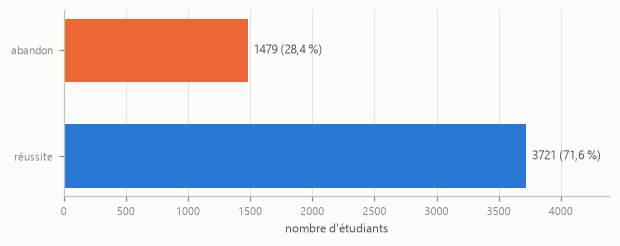

Prévalence de l'abandon **28.4 %** · rapport de déséquilibre **2.5:1**

In [7]:
# Barres horizontales : une couleur par classe, l'étiquette porte l'effectif ET la part.
balance = (
    eda.class_balance(cible_abandon)
    .assign(classe=lambda d: d["modalite"].map({"0": "réussite", "1": "abandon"}))
    .dropna(subset=["classe"])
    .sort_values("n", ascending=False)  # réussite en bas, abandon en haut
)
COULEURS = {"réussite": eda.PALETTE["series_1"], "abandon": eda.PALETTE["series_2"]}

figure, axis = plt.subplots(figsize=(6.4, 2.2))
axis.barh(
    balance["classe"], balance["n"], color=[COULEURS[c] for c in balance["classe"]], height=0.6
)
for y, (n, part) in enumerate(zip(balance["n"], balance["part_%"], strict=True)):
    axis.text(
        n,
        y,
        f"  {n} ({part:.1f} %)".replace(".", ","),
        va="center",
        ha="left",
        fontsize=8,
        color=eda.PALETTE["ink_secondary"],
    )
axis.set_xlabel("nombre d'étudiants")
axis.set_xlim(0, int(balance["n"].max() * 1.18))
axis.grid(axis="y", visible=False)
eda.show(figure)

display(
    Markdown(
        f"Prévalence de l'abandon **{100 * cible_abandon.mean():.1f} %** · "
        f"rapport de déséquilibre **{eda.imbalance_ratio(cible_abandon):.1f}:1**"
    )
)

### Interprétation

- La cible est déséquilibrée, mais pas au point de fausser l'apprentissage : **28,4 % d'abandon** contre 71,6 % de réussite, soit un rapport de 2,5:1. Deux conséquences en découlent :
  - l'écart est assez marqué pour qu'un modèle prédisant toujours « pas d'abandon » atteigne 71,6 % d'accuracy sans aucune valeur prédictive - l'évaluation se fera donc au rappel, au F1 et à l'AUC, jamais sur la seule accuracy ;
  - il reste trop modéré pour justifier un ré-échantillonnage (confirme D10) ; une pondération des classes (`class_weight`) suffira si besoin, à trancher au choix du modèle (§8/§9).

## 6.2 Lien entre les deux cibles

Les deux cibles sont-elles indépendantes, ou `abandon` n'est-il que le seuillage de `moyenne_finale` ?

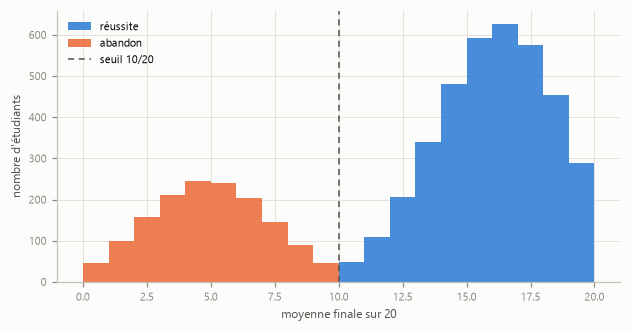

**Meilleur note d'un décrocheur** : 9.92<br>**Pire note d'un reçu** : 10.03<br>`abandon == (moyenne_finale < 10)` sur **100 %** des lignes

In [8]:
SEUIL_VALIDATION = 10  # une moyenne finale >= 10/20 vaut validation de l'année
recouvrement = jeu.groupby(cible_abandon)["moyenne_finale"].agg(["min", "max"])
coincide = (cible_abandon == (cible_moyenne < SEUIL_VALIDATION)).mean()

figure, axis = plt.subplots(figsize=(6.6, 3.2))
bornes = range(0, 21)
axis.hist(
    eda.as_float(cible_moyenne[cible_abandon == 0]),
    bins=bornes,
    color=eda.PALETTE["series_1"],
    alpha=0.85,
    label="réussite",
)
axis.hist(
    eda.as_float(cible_moyenne[cible_abandon == 1]),
    bins=bornes,
    color=eda.PALETTE["series_2"],
    alpha=0.85,
    label="abandon",
)
axis.axvline(
    SEUIL_VALIDATION,
    color=eda.PALETTE["ink_secondary"],
    linewidth=1.0,
    linestyle=(0, (4, 3)),
    label=f"seuil {SEUIL_VALIDATION}/20",
)
axis.set_xlabel("moyenne finale sur 20")
axis.set_ylabel("nombre d'étudiants")
axis.legend(loc="upper left")
eda.show(figure)

display(
    Markdown(
        f"**Meilleur note d'un décrocheur** : {recouvrement.loc[1, 'max']:g}<br>"
        f"**Pire note d'un reçu** : {recouvrement.loc[0, 'min']:g}<br>"
        f"`abandon == (moyenne_finale < {SEUIL_VALIDATION})` "
        f"sur **{100 * coincide:.0f} %** des lignes"
    )
)

### Interprétation

- **Les deux nuages ne se recouvrent pas** : le pire des reçus reste au-dessus du meilleur des décrocheurs. `abandon` n'est donc rien d'autre que `moyenne_finale` seuillée à 10/20 - la validation de l'année. La conséquence est double. `moyenne_finale` ne peut servir de variable explicative d'`abandon`, sous peine d'une fuite triviale - prédire le seuil à partir de la valeur seuillée. Elle reste pour autant une cible à part entière, traitée en régression pour prioriser et calibrer l'accompagnement (§2).

## 6.3 Distribution des variables explicatives

Je profile chaque explicative pour en connaître la **forme** - centre, dispersion et asymétrie des numériques, équilibre des modalités des catégorielles - et repérer ce qui appelle une décision de principe : variance nulle, échelles à harmoniser, modalité trop rare pour le découpage train / test.

,colonne,n_renseigne,moyenne,ecart_type,min,mediane,max,asymetrie
0,age,5200,19.80,1.88,17.0,20.0,27.0,0.67
1,distance_domicile_km,4888,15.17,15.07,0.0,10.4,138.0,1.94
2,heures_travail_remunere_sem,4576,9.59,8.46,0.0,9.0,28.0,0.44
3,taux_presence_pct,5200,77.56,12.09,34.8,77.9,99.9,-0.24
4,connexions_lms_30j,4992,28.07,14.22,0.0,28.0,81.0,0.24
5,heures_lms_total,5200,42.25,25.25,0.0,39.0,170.5,0.72
6,ressources_consultees,5200,61.81,34.17,0.0,59.0,222.0,0.46
7,retards_rendus,5200,3.74,2.15,0.0,4.0,10.0,0.18
8,nb_devoirs_total,5200,10.49,1.70,8.0,10.0,13.0,0.01
9,nb_devoirs_rendus,5200,8.51,2.06,0.0,8.0,13.0,0.12


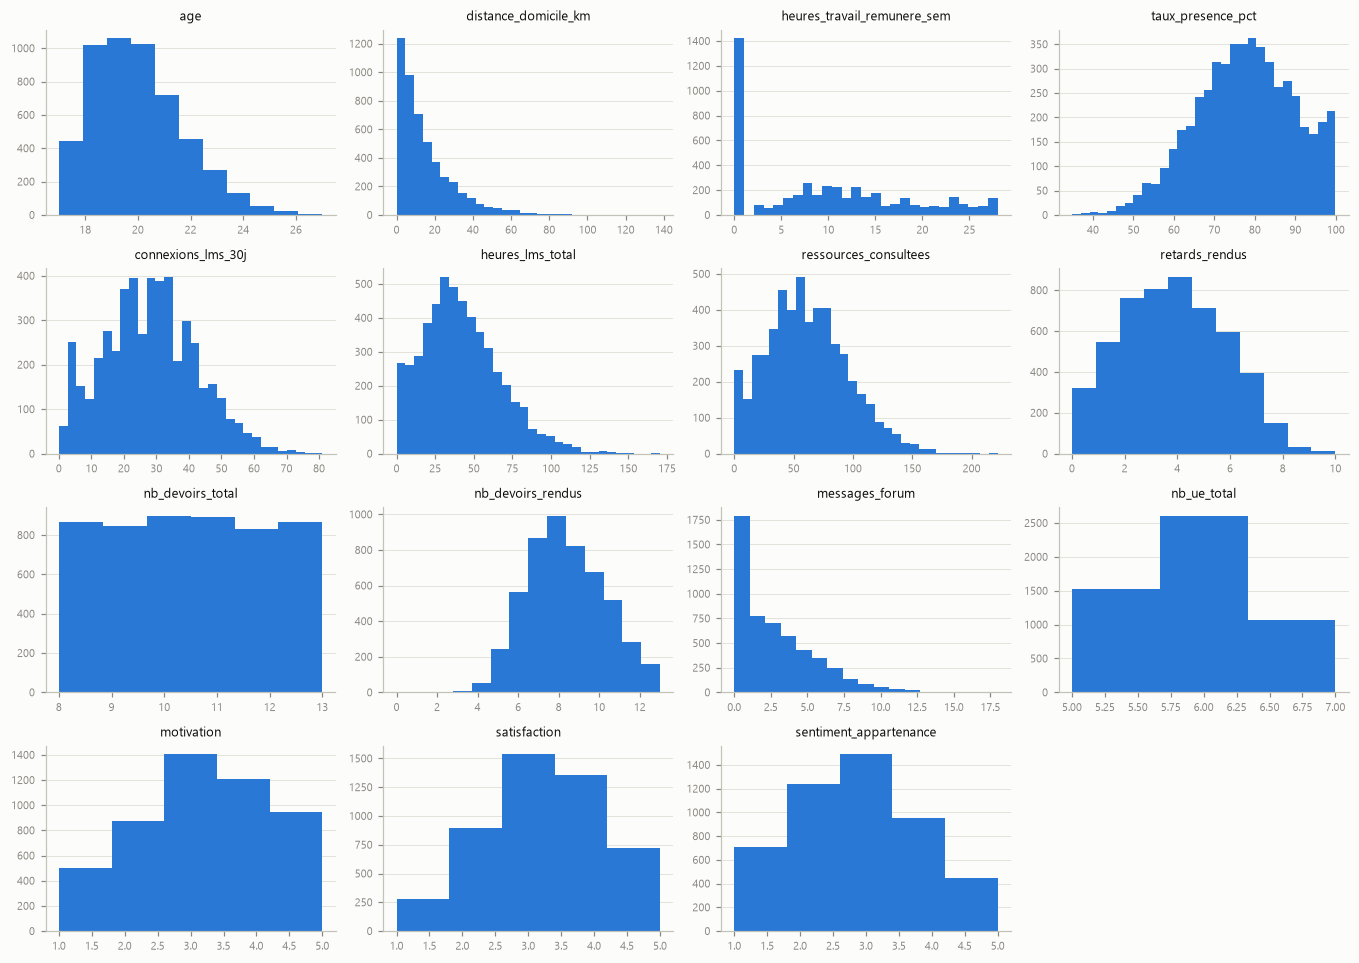

In [9]:
display(eda.numeric_overview(jeu[num_cols]))
eda.show(eda.plot_histograms(jeu[num_cols]))

,colonne,n_modalites,dominante,part_dominante_%,plus_rare,part_rare_%,manquants_%
0,annee_universitaire,1,2024-2025,100.00,2024-2025,100.00,0.0
1,filiere,8,informatique,16.50,lettres,8.15,0.0
2,sexe,4,femme,54.31,non renseigné,0.60,0.0
3,bac_type,3,general,61.48,professionnel,11.56,0.0
4,mention_bac,4,passable,39.10,tres bien,8.87,4.0
5,etablissement_origine,4,lycee_public,69.33,autre,4.17,5.0
6,boursier,2,non,62.02,oui,37.98,0.0
7,groupe_td,8,b,13.23,f,11.15,0.0
8,couleur_carte_etudiante,5,jaune,20.63,vert,19.35,0.0
9,jour_inscription,5,mardi,21.52,lundi,18.96,0.0


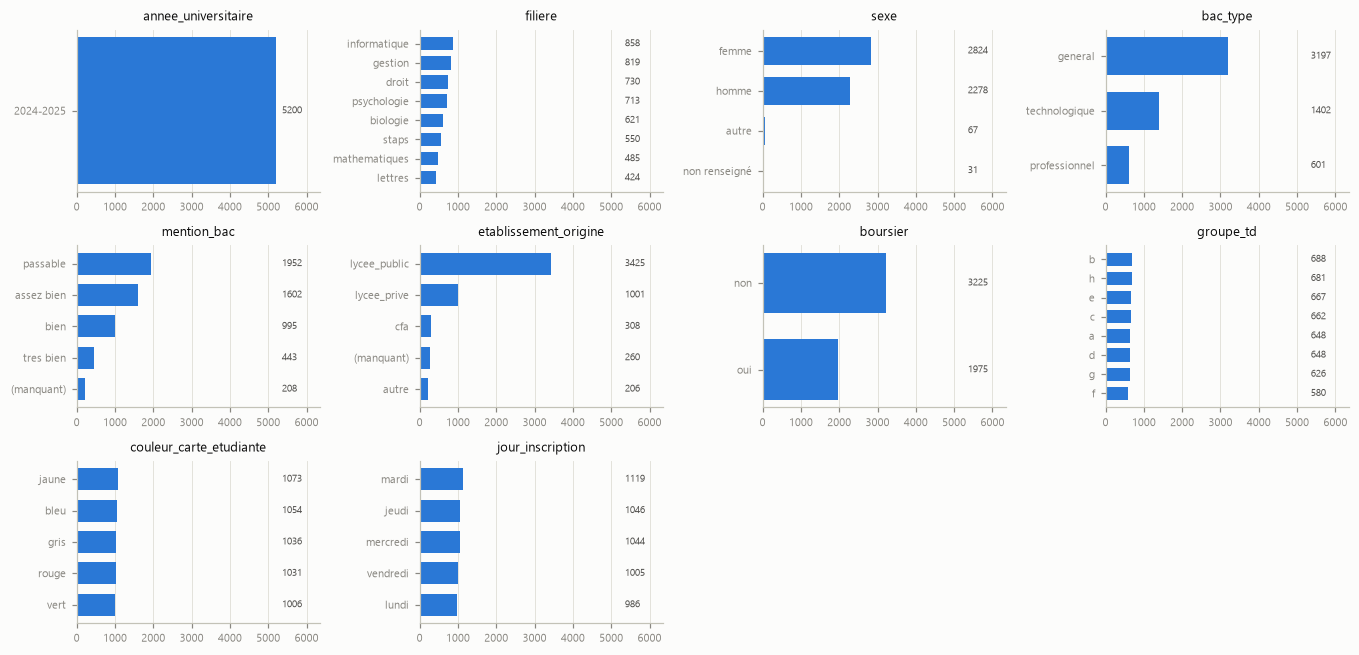

**> Modalités rares (< 5 %)**

,colonne,modalite,n,part_%
0,sexe,autre,67,1.29
1,sexe,non renseigné,31,0.60
2,etablissement_origine,autre,206,4.17


In [10]:
display(eda.modality_overview(jeu[cat_cols]))
eda.show(eda.plot_bars({c: eda.modality_counts(jeu[c]) for c in cat_cols}, labels="{:.0f}"))

display(Markdown("**> Modalités rares (< 5 %)**"))
display(eda.rare_modalities(jeu[cat_cols], max_share=0.05))

### Interprétation

Le profilage des explicatives ne révèle aucune anomalie de forme, seulement des points à traiter plus loin dans la chaîne.

- **Forme des numériques** 
  - Asymétrie : une seule variable est nettement asymétrique, `distance_domicile_km` (asymétrie 1,94, moyenne 15,2 > médiane 10,4), à imputer par la médiane (§6.4) ; `messages_forum` frôle le seuil (0,95) mais est complète, sans imputation à prévoir. 
  - Echelle : Les échelles sont très hétérogènes - de 1-5 (`motivation`) à 0-222 (`ressources_consultees`) - d'où une standardisation à placer dans le `Pipeline` (§8) dans le cas où le modèle choisi est une régression logistique.

- **Une constante à écarter** 
  - `annee_universitaire` ne porte qu'**une seule modalité** (`2024-2025`, 100 %) : variance nulle, aucun pouvoir prédictif - écartée de principe.
  - aucune autre variance nulle parmi les explicatives - écarts-types tous > 0, dominante la plus forte 69 % pour `etablissement_origine`.

- **Modalités des catégorielles** 
  - `filiere` (8 modalités, 8-17 %), `boursier` (38/62), `bac_type` et `mention_bac` sont équilibrées, rien de dégénéré.
  - Les trois leurres `couleur_carte_etudiante`, `groupe_td`, `jour_inscription` sont quasi uniformes (~20 % par modalité), cohérent avec des variables décoratives (§6.8). 
  - **Trois modalités rares (< 5 %)** portent sur `sexe` (« autre », « non renseigné ») et `etablissement_origine` (« autre ») - des modalités **déclarées**, pas des manquants, transmises telles quelles à l'encodeur (`handle_unknown="ignore"`, §8) pour ne pas disparaître au découpage train / test. Le repérage annoncé en §4.5 se règle ici : `sexe` est **hors modèle** (protégée, D13), sa rareté ne biaise aucune prédiction - laissée à l'audit d'équité (§12, D17) ; `etablissement_origine` (proxy, D14) **entre dans la comparaison** (maintien tranché en §8), mais « autre » étant déjà le fourre-tout, elle n'est pas regroupable - **signalée zone de moindre fiabilité** et couverte par le même audit.

## 6.4 Valeurs manquantes

§5 a compté les valeurs absentes ; reste à décider de leur **traitement**. Le mécanisme d'une absence ne s'observe pas (§3.4, D09) - je ne cherche pas à le prouver, mais à répondre aux **deux questions dont dépend le traitement** :

- **structure** - les trous se donnent-ils rendez-vous sur les mêmes dossiers ? (matrice et carte de nullité) - une concentration ouvrirait la voie à une suppression de lignes ;
- **signal** - manquer va-t-il de pair avec l'abandon ? Un manque informatif appellerait un **indicateur `x_manquant`** pour ne pas effacer ce qu'il porte ; un manque sans lien avec l'issue non.

,colonne,n_manquants,part_%
0,heures_travail_remunere_sem,624,12.0
1,satisfaction,416,8.0
2,sentiment_appartenance,364,7.0
3,distance_domicile_km,312,6.0
4,motivation,260,5.0
5,etablissement_origine,260,5.0
6,mention_bac,208,4.0
7,connexions_lms_30j,208,4.0


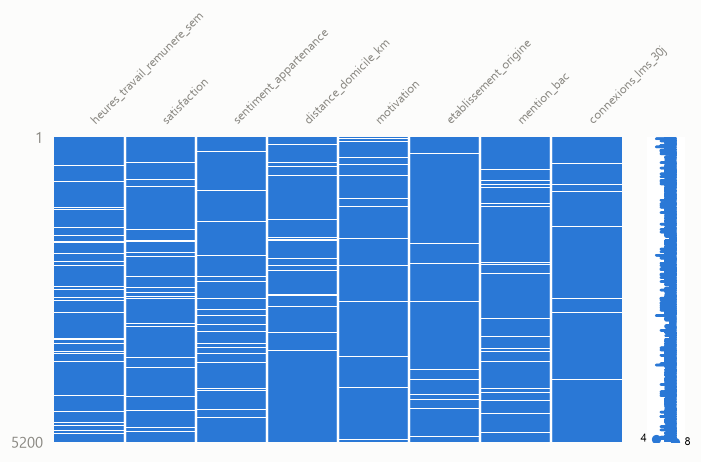

In [11]:
troues = eda.missing_overview(jeu[explicatives])
display(troues)

# Structure des trous : où sont-ils, et se donnent-ils rendez-vous sur les mêmes lignes ?
cols_troues = troues["colonne"].tolist()
eda.show(eda.plot_missing_matrix(jeu[cols_troues]))

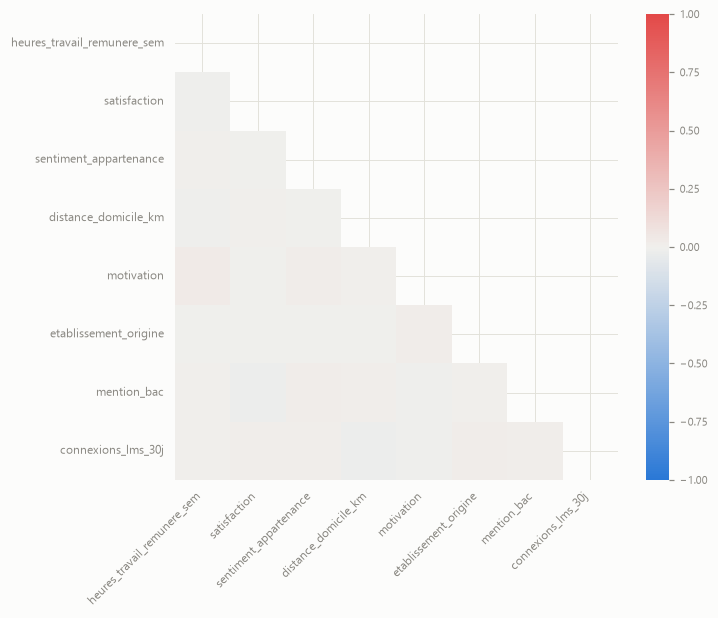

In [12]:
# Par paires : deux colonnes manquent-elles ensemble ? (corrélation de nullité φ)
eda.show(eda.plot_missing_heatmap(jeu[cols_troues]))

,colonne,n_manquants,taux_si_manquant_%,taux_si_present_%,ecart_pt,bruit_95_pt,p_permutation
0,heures_travail_remunere_sem,624,30.93,28.10,2.83,3.73,0.1517
1,satisfaction,416,26.44,28.62,-2.17,4.37,0.3892
2,sentiment_appartenance,364,29.95,28.33,1.62,4.87,0.5210
3,connexions_lms_30j,208,27.40,28.49,-1.08,5.93,0.7465
4,distance_domicile_km,312,27.56,28.50,-0.93,5.54,0.7505
5,etablissement_origine,260,29.23,28.40,0.83,5.65,0.7804
6,mention_bac,208,28.37,28.45,-0.08,6.11,1.0000
7,motivation,260,28.46,28.44,0.02,5.24,1.0000


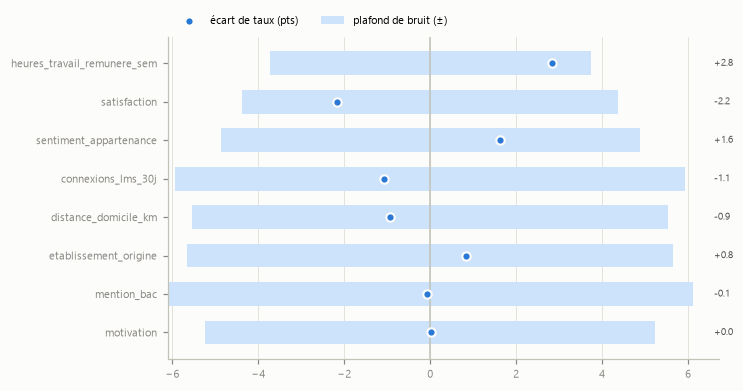

In [13]:
# Signal : l'absence va-t-elle de pair avec l'abandon ? (oriente l'ajout d'un indicateur x_manquant)
ecarts = eda.missing_vs_target(jeu[explicatives], cible_abandon)
display(ecarts)
eda.show(
    eda.plot_intervals(
        ecarts.set_index("colonne"),
        value="ecart_pt",
        span="bruit_95_pt",
        labels="{:+.1f}",
        legend=("plafond de bruit (±)", "écart de taux (pts)"),
    )
)

### Interprétation

Le mécanisme d'une absence ne s'observe pas directement ; §3.4 (D09) l'a contourné par deux questions dont la réponse commande le traitement. L'EDA les tranche ici dans l'ordre : d'abord la structure des trous - se concentrent-ils ? -, puis leur signal - vont-ils de pair avec l'abandon ?

1. Les trous se concentrent-ils sur les mêmes dossiers ?

    La réponse décide s'il est envisageable de supprimer des lignes plutôt que d'imputer : la suppression n'aurait de sens que si une poignée de dossiers portaient l'essentiel des absences, et à la double condition d'une perte négligeable et d'une absence plausiblement aléatoire.

    - **Aucune corrélation entre colonnes** - la carte de nullité ne fait ressortir aucun coefficient qui se distingue de 0 : l'absence d'une colonne n'entraîne pas celle d'une autre.
    - **Aucune concentration par dossier** - la matrice de nullité montre des traits clairs dispersés, sans bande alignée : aucune ligne ne cumule les absences.

    Les trous sont diffus, répartis sur tout le jeu : la condition n'est pas réunie, aucune ligne n'est retirée. La supprimer biaiserait le jeu dès que l'absence n'est pas purement aléatoire, et sacrifierait des décrocheurs (classe rare) sans contrepartie.

2. L'absence est-elle un signal ? (lien avec `abandon`)

    La réponse décide s'il faut, avant d'imputer, ajouter un indicateur binaire `x_manquant` : il n'est utile que si le fait de manquer va de pair avec l'issue, auquel cas effacer le trou effacerait une information.

    - **Écarts dans le bruit** - entre présents et absents, chaque écart de taux d'abandon reste dans sa bande de bruit, au plus +2,8 pt pour un plafond de 3,7.
    - **Aucun écart significatif** - tous les tests donnent p ≥ 0,15, très au-dessus du seuil usuel de 0,05 en deçà duquel un lien se distinguerait du hasard.

    Manquer ne prédit donc pas l'abandon : aucun indicateur `x_manquant` n'est justifié, l'absence ne portant rien qu'il faille conserver.

**Conclusion** 

Aucune des deux conditions qui appelleraient un autre traitement n'est réunie - ni concentration (pas de suppression de lignes), ni signal (pas d'indicateur `x_manquant`) : l'imputation relève du `Pipeline`, sur le train seul (§8) ; les options ouvertes par D09 restent en jeu - **médiane**, **mode**, ou **valeur fixe** si l'absence est porteuse de sens. Ce choix concret, variable par variable, ne relève pas de l'EDA - il est appliqué en §8.

## 6.5 Valeurs extrêmes

Je cherche les valeurs **rares** par la règle de Tukey (écart interquartile, k = 1,5), sur les seules variables que le métier **ne borne pas**. Les échelles à domaine fixe - accord 1-5, pourcentage 0-100 - sont déjà contrôlées par leurs bornes en §5.3 ; les y soumettre confondrait le *rare* et le *légitime* (une échelle 1-5 ferait passer la réponse « 1 » pour une anomalie). L'IQR dit ici ce qui est **rare**, jamais ce qui est **faux**.

,colonne,min,max,borne_basse,borne_haute,n_hors_iqr,part_%
0,distance_domicile_km,0.0,138.0,-20.40,46.00,235,4.81
1,heures_lms_total,0.0,170.5,-26.15,107.85,77,1.48
2,ressources_consultees,0.0,222.0,-32.00,152.00,49,0.94
3,messages_forum,0.0,18.0,-5.00,11.00,34,0.65
4,age,17.0,27.0,13.50,25.50,27,0.52
5,connexions_lms_30j,0.0,81.0,-12.00,68.00,19,0.38
6,retards_rendus,0.0,10.0,-2.50,9.50,13,0.25
7,nb_devoirs_rendus,0.0,13.0,2.50,14.50,7,0.13
8,heures_travail_remunere_sem,0.0,28.0,-22.50,37.50,0,0.00
9,nb_devoirs_total,8.0,13.0,4.50,16.50,0,0.00


**419** lignes portent au moins une valeur hors IQR (sur 5200)

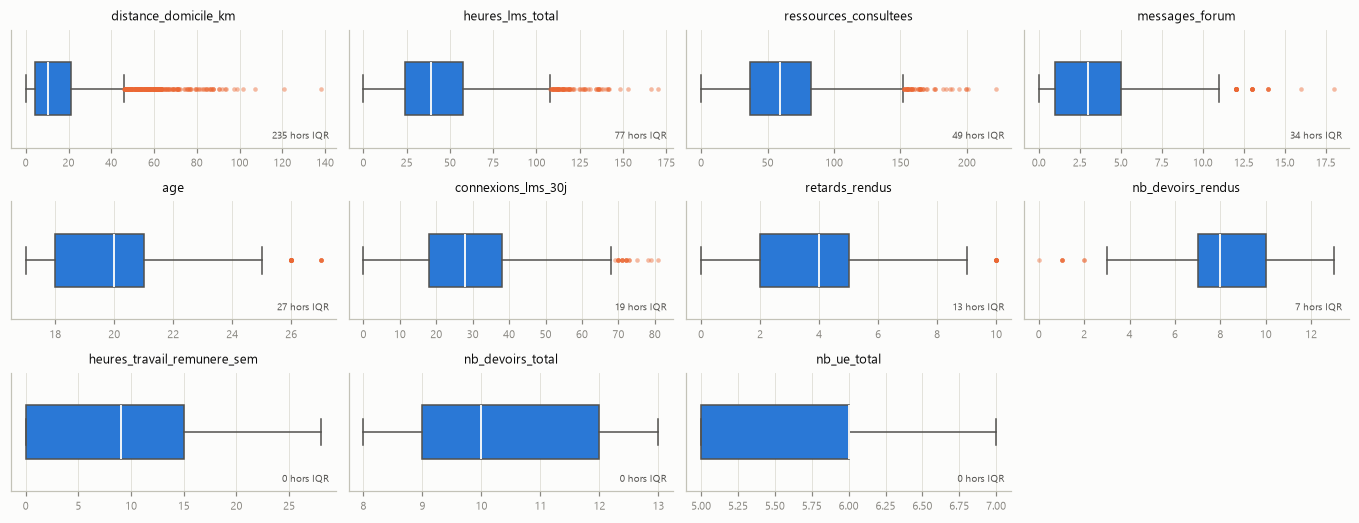

In [14]:
# Règle de Tukey (k = 1,5) : borne_basse = Q1 - 1,5·IQR, borne_haute = Q3 + 1,5·IQR.
# Variables à domaine métier borné (échelles 1-5, pourcentage 0-100) : déjà contrôlées
# par leurs bornes en §5.3 - exclues ici, où Tukey confondrait le rare et le légitime.
BORNEES = ["taux_presence_pct", "motivation", "satisfaction", "sentiment_appartenance"]
non_bornees = [c for c in num_cols if c not in BORNEES]

extremes = eda.iqr_outliers(jeu[non_bornees])
display(extremes)
ordre = extremes["colonne"].tolist()  # graphiques alignés sur le tableau trié
masque = eda.iqr_mask(jeu[non_bornees])
display(
    Markdown(
        f"**{int(masque.any(axis=1).sum())}** lignes portent au moins une valeur hors IQR "
        f"(sur {len(jeu)})"
    )
)
eda.show(
    eda.plot_boxplots(
        jeu[ordre],
        annotations={r.colonne: f"{r.n_hors_iqr} hors IQR" for r in extremes.itertuples()},  # type: ignore
    )
)

### Interprétation

La règle de Tukey signale des valeurs rares, pas des valeurs fausses : reste à décider, au sens métier, si chaque extrême est une erreur à corriger (écrêtage, mise à l'écart) ou un profil réel à conserver.

- **Des queues à droite, toutes plausibles** - la règle ne relève que des valeurs hautes, jamais négatives (`min ≥ 0` partout), et aucune ne sort du domaine possible :
  - `distance_domicile_km` (jusqu'à 138 km), `heures_lms_total`, `ressources_consultees`, `messages_forum`, `connexions_lms_30j` : de l'engagement numérique et de l'éloignement, avec quelques profils extrêmes mais bien réels ;
  - `age` : borne haute vers 25,5 ans, quelques 26-27 - des reprises d'études, plausibles en L1.

Aucune valeur n'est anormale au sens métier : le rare est réel, rien n'est faux. Aucun écrêtage ni retrait n'est justifié - corriger ces extrêmes effacerait des étudiants qui existent.

## 6.6 Associations entre explicatives

Je mesure les liens **entre variables explicatives** - le seul terrain où une redondance justifie d'écarter une colonne. Une carte d'association **0→1 tous types confondus** (V de Cramér, η, |ρ| selon la paire) situe toutes les liaisons, catégorielle/numérique comprises ; une seconde carte, la corrélation **signée** de Spearman, rend le sens dans le bloc numérique.

Le lien **explicative↔cible n'est pas mesuré ici** : en présumer un pouvoir prédictif orienterait les choix de features sur la cible - ce que je m'interdis - et n'induirait qu'un a priori que l'explicabilité du modèle (§12, SHAP) peut démentir. Les seules mesures faisant intervenir la cible dans §6 démontrent une **absence** (leurres, §6.8) ou protègent un attribut (non-ré-encodage de `boursier`, §6.7).

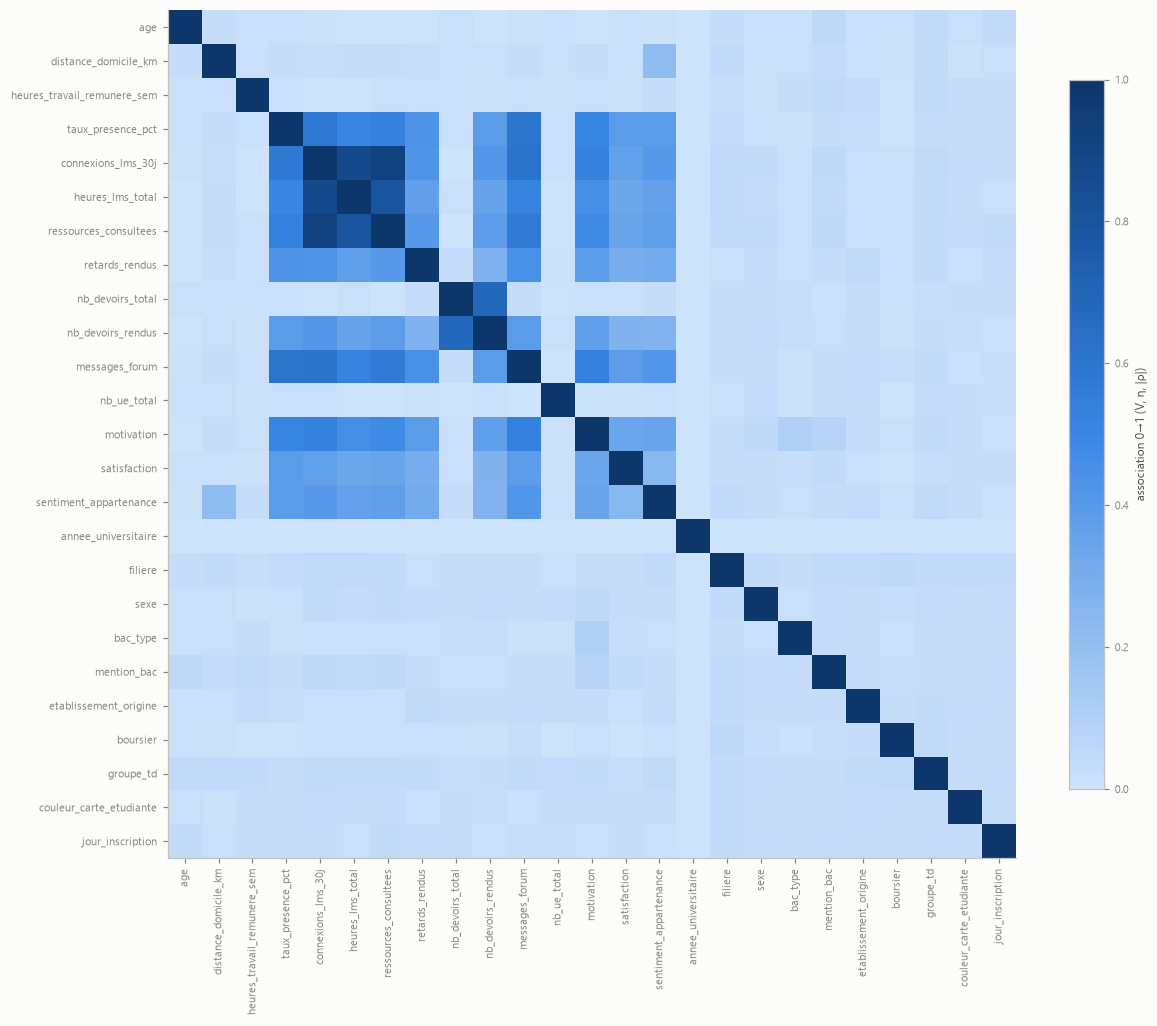

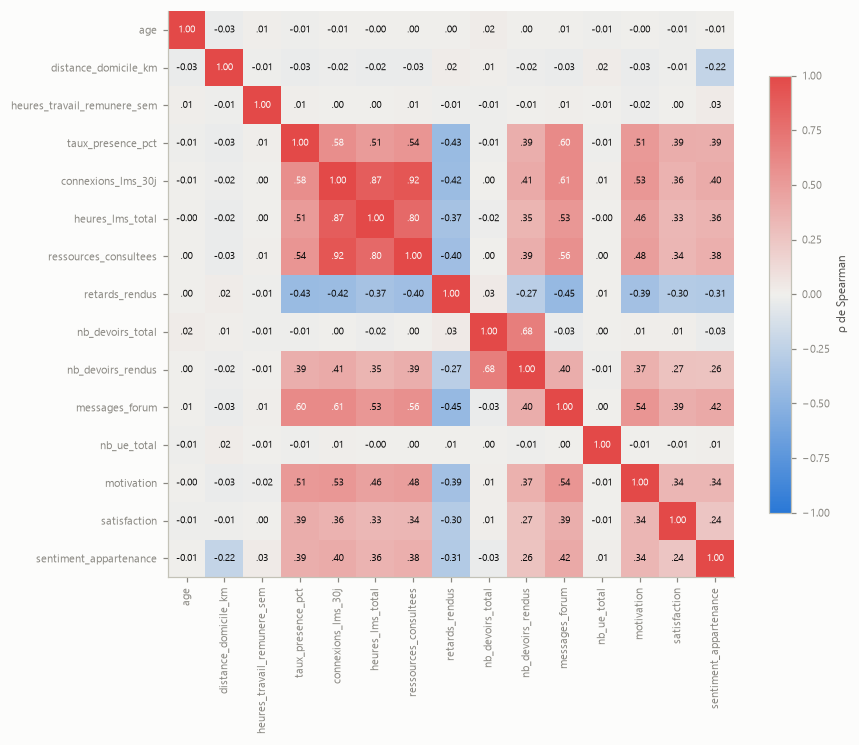

**> Corrélations numériques fortes (|ρ| >= 0,8)**

,variable_1,variable_2,correlation
0,connexions_lms_30j,ressources_consultees,0.920
1,connexions_lms_30j,heures_lms_total,0.869


In [15]:
# Entre explicatives - le seul terrain où une redondance justifie d'écarter une colonne.
# Carte unifiée 0→1 (V de Cramér, η ou |ρ| selon la nature de la paire) : elle situe TOUTES les
# associations, y compris les couples catégorielle/numérique qu'aucune matrice par type ne voit.
# La carte signée de Spearman rend ensuite le sens que la première aplatit ; le tableau ne garde
# que les redondances fortes.
eda.show(
    eda.plot_heatmap(
        eda.association_matrix(jeu, num_cols, cat_cols),
        diverging=False,
        annotate=False,
        label="association 0→1 (V, η, |ρ|)",
    )
)
eda.show(
    eda.plot_heatmap(
        eda.correlation_matrix(jeu[num_cols]),
        diverging=True,
        annotate=True,
        label="ρ de Spearman",
    )
)
display(Markdown("**> Corrélations numériques fortes (|ρ| >= 0,8)**"))
display(eda.correlation_pairs(jeu[num_cols], threshold=0.8))

### Interprétation

La carte unifiée sépare deux régimes : un bloc numérique structuré, tout le reste au niveau du fond.

- **Catégorielles mutuellement indépendantes**, et indépendantes des numériques - leur bloc reste partout au niveau du fond, aucune liaison ne s'en détache. Rien à écarter pour redondance de ce côté.
- **Un bloc d'engagement** porte presque toute la structure numérique : présence, activité LMS, forum, devoirs rendus et ressenti déclaré co-varient, `retards_rendus` en négatif - l'attitude déclarée s'aligne sur le comportement observé.
- **Trio LMS quasi-redondant** - `connexions_lms_30j`, `ressources_consultees`, `heures_lms_total` co-varient de ρ 0,80 à 0,92 (les deux paires du tableau) : trois mesures d'une même activité.
- **Quatre variables isolées** - `age`, `distance_domicile_km`, `heures_travail_remunere_sem`, `nb_ue_total` ne rejoignent aucun bloc (`distance` frôle seule `sentiment_appartenance`, ρ −0,22).

Cette structure est de la **redondance, pas du pouvoir prédictif** - ces variables recouvrent la même information. Deux conséquences, aucune décision ici :

- **Modèle (§8)** - la colinéarité déstabilise un linéaire (à régulariser), laisse un ensemble d'arbres indifférent : argument pour comparer les deux familles.
- **Explicabilité (§12)** - SHAP répartira l'importance entre variables corrélées ; le trio LMS partagera un crédit qu'une seule paraîtrait mériter, à lire en groupe.

**Aucun retrait en §6** - même le trio traverse le gold : on mesure avant de retirer (D16), le retrait des redondantes - en garder une - se décidera par ablation (§8), pas sur une corrélation entre explicatives ; SHAP (§12) le confirmera.

## 6.7 Non-ré-encodage d'un attribut protégé - proxies vs `boursier`

`boursier` est exclu du modèle par principe (§4.4) ; reste à vérifier qu'aucun proxy socio-économique ne le **ré-encode** par une porte dérobée - ce serait une discrimination indirecte. 

Je mesure le lien de chaque proxy candidat avec `boursier` sur une échelle **0 (indépendance) → 1 (déterminisme)**, comparable d'un type à l'autre - **V de Cramér** pour la catégorielle, **rapport de corrélation η** pour les numériques - lu contre son **plafond de bruit** par permutation. Sur 5 200 lignes, la p-valeur ne tranche pas à elle seule ; c'est la **magnitude** qui dit s'il y a ré-encodage.

,colonne,type,mesure,association,bruit_95,p_permutation
0,etablissement_origine,catégorielle,V de Cramér,0.027,0.044,0.4711
1,distance_domicile_km,numérique,η,0.007,0.027,0.6727
2,heures_travail_remunere_sem,numérique,η,0.003,0.031,0.8263


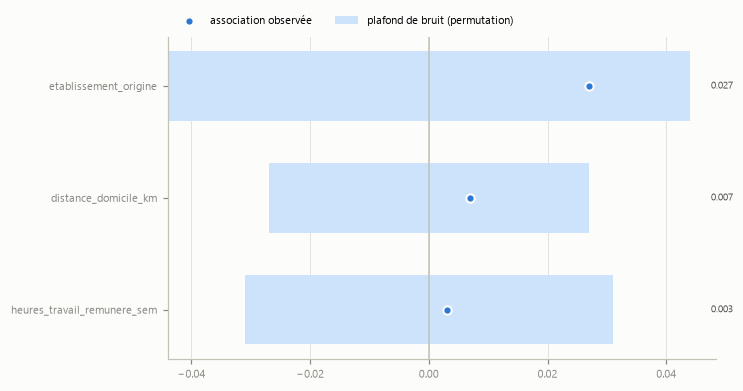

In [16]:
# D14 (§4.4) : un proxy socio-économique ré-encode-t-il `boursier` (protégé, exclu) ? Mesure 0→1
# comparable entre types - V de Cramér (catégorielle) ou η (numérique) - lue contre son bruit.
PROXIES = ["etablissement_origine", "heures_travail_remunere_sem", "distance_domicile_km"]
proximite = eda.association_with(jeu, PROXIES, jeu["boursier"])
display(proximite)
eda.show(
    eda.plot_intervals(
        proximite.set_index("colonne"),
        value="association",
        span="bruit_95",
        labels="{:.3f}",
        legend=("plafond de bruit (permutation)", "association observée"),
    )
)

### Interprétation

- **Les trois proxies sous leur plafond de bruit** - `etablissement_origine` (V 0,027 < 0,044) · `distance_domicile_km` (η 0,007 < 0,027) · `heures_travail_remunere_sem` (η 0,003 < 0,031), p ≥ 0,47 : aucun ne ré-encode `boursier`.
- Le lien avec `boursier` est **indiscernable du hasard** - aucune discrimination indirecte à redouter.

La décision qui en résulte - l'entrée des trois proxies au modèle - est portée au **journal [D14]**.

## 6.8 Leurres annoncés

Trois variables annoncées comme décoratives (§3.6) - `groupe_td`, `couleur_carte_etudiante`, `jour_inscription`. Plutôt que de les croire nulles, je le **démontre** par deux contrôles :

- une **redondance déterministe** - `jour_inscription` se recalcule-t-il depuis `date_inscription` ?
- un **lien bivarié avec `abandon`**, jugé sur sa magnitude.

Le poids multivarié - le seul qui tranche vraiment - se lira en §12 (SHAP). Elles restent dans le gold jusque-là.

In [17]:
# `jour_inscription` se recalcule-t-il depuis `date_inscription` ? (dérivation déterministe)
JOURS = {
    0: "lundi",
    1: "mardi",
    2: "mercredi",
    3: "jeudi",
    4: "vendredi",
    5: "samedi",
    6: "dimanche",
}
jour_recalcule = jeu["date_inscription"].dt.weekday.map(JOURS)
comparables = jeu["jour_inscription"].notna() & jour_recalcule.notna()
coincide_jour = (jeu.loc[comparables, "jour_inscription"] == jour_recalcule[comparables]).mean()
display(
    Markdown(
        f"`jour_inscription` = jour de semaine de `date_inscription` sur "
        f"**{100 * coincide_jour:.1f} %** des lignes comparables"
    )
)

`jour_inscription` = jour de semaine de `date_inscription` sur **100.0 %** des lignes comparables

,colonne,type,mesure,association,bruit_95,p_permutation
0,couleur_carte_etudiante,catégorielle,V de Cramér,0.045,0.041,0.0299
1,jour_inscription,catégorielle,V de Cramér,0.039,0.043,0.0938
2,groupe_td,catégorielle,V de Cramér,0.033,0.051,0.5449


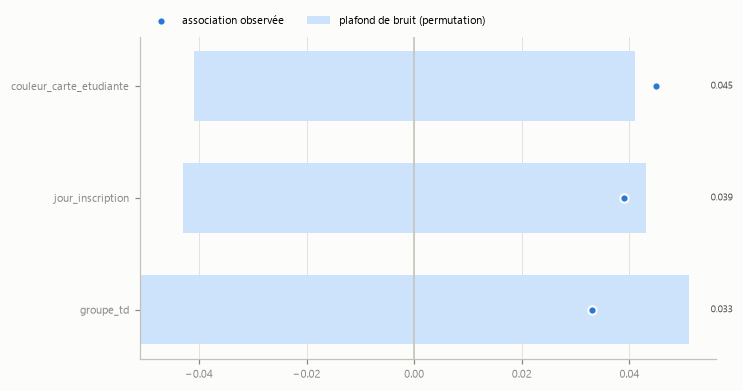

In [18]:
# Point 2 - le lien de chaque leurre avec la cible sort-il du bruit ? Même mesure et même
# lecture qu'en §6.7, `abandon` remplaçant l'attribut protégé.
LEURRES = ["groupe_td", "couleur_carte_etudiante", "jour_inscription"]
liens_leurres = eda.association_with(jeu, LEURRES, cible_abandon)
display(liens_leurres)
eda.show(
    eda.plot_intervals(
        liens_leurres.set_index("colonne"),
        value="association",
        span="bruit_95",
        labels="{:.3f}",
        legend=("plafond de bruit (permutation)", "association observée"),
    )
)

### Interprétation

Deux contrôles convergents ; l'un livre un résultat contraire à l'attendu, à ne pas surinterpréter.

- `jour_inscription` **reproduit intégralement** le jour de semaine de `date_inscription` : une réécriture sans information propre, sans intérêt prédictif au-delà de `date_inscription`.
- `groupe_td` et `jour_inscription` restent **dans leur bande de bruit** : leur lien bivarié avec `abandon` est indiscernable du hasard - l'attendu pour un leurre.
- **`couleur_carte_etudiante` sort de sa bande** - contraire à l'attendu pour un leurre. L'écart tient à la *taille de l'effet*, non à sa réalité : le V reste infime, collé à zéro, et connaître la couleur de carte ne déplace quasiment pas la probabilité d'abandon. Sur 5 200 lignes, un effet négligeable devient « significatif » (p < 0,05) sans cesser d'être négligeable - **la magnitude mesure le pouvoir prédictif ; la p-valeur, seulement l'existence du lien** (§6.7).
- Le bivarié ne tranche pas seul - un leurre pourrait peser par interaction, ou ne pas peser malgré un lien brut. Le **verdict du retrait revient à l'ablation multivariée** : §8 mesurera le coût de retrait des leurres - nul attendu - et actera leur suppression par minimisation (D11, D16), que §12 (SHAP) confirmera au niveau variable.

## _Journal de bord des décisions_

1. **[D22] Seuil de rareté des modalités - 5 %**  
⇒ Le repérage des modalités sous-représentées annoncé en §4.5 se tranche ici. Seuil à **5 %** : au-dessous, l'effectif d'un groupe (quelques dizaines de lignes, une poignée de décrocheurs) est trop mince pour qu'un audit d'équité en conclue quoi que ce soit. Le seuil fait remonter `etablissement_origine = autre` (proxy au modèle, D14), invisible à 1 % - déjà le fourre-tout, non regroupable, donc signalée zone de moindre fiabilité et couverte par l'audit §12 (D17) ; les modalités rares de `sexe` (protégée, D13) restent hors modèle et relèvent du même audit. *Écarté* - **1 %** : ne garantissait que la survie au découpage train / test, déjà assurée par `handle_unknown="ignore"`, et manquait la seule modalité rare réellement dans le modèle.

1. **[D09] Manquants - imputation par défaut : médiane/mode, sans indicateur, sans suppression**  
⇒ Diagnostic mené en §6. Ni **concentration** (trous diffus, aucun dossier ne les cumule - pas de suppression de lignes), ni **signal** (l'absence ne va pas de pair avec l'abandon - pas d'indicateur `x_manquant`) : l'imputation relève du `Pipeline`, train seul (anti-fuite, §8) : les options ouvertes par D09 restent en jeu - médiane, mode, ou valeur fixe si l'absence a une signification propre - le choix concret par colonne est appliqué en §8. *Écarté* - **supprimer les lignes trouées** : les trous étant diffus, on sacrifierait des décrocheurs (classe rare) sans contrepartie. *Écarté* - **un indicateur `x_manquant`** : justifié seulement si l'absence prédit l'issue, ce que la mesure infirme.

1. **[D19] Extrêmes (Tukey) - ni écrêtage ni retrait**  
⇒ Les queues hautes signalées sont rares mais **réelles** : toutes dans le domaine possible, aucune aberrante au sens métier. Conservées telles quelles dans le gold. *Écarté* - **winsoriser / écrêter** : corrigerait un problème qui n'existe pas et effacerait des profils réels (éloignés, reprises d'études) susceptibles de porter le signal.

1. **[D20] Colinéarité (bloc d'engagement) - aucun retrait en §6, différé à l'ablation §8**  
⇒ Le trio LMS (`connexions_lms_30j`, `ressources_consultees`, `heures_lms_total`) mesure une même activité ; les trois traversent le gold, le retrait éventuel - en garder une - se décide par ablation (§8) - la redondance n'est pas un pouvoir prédictif, un ensemble d'arbres l'encaisse, l'ablation tranche en multivarié et SHAP (§12) confirme. *Écarté* - **retirer une des trois dès §6** sur la seule corrélation : présume ce que l'ablation §8 doit mesurer. Généralise l'esprit de D16 (mesurer avant de trancher le retrait).

1. **[D14] Proxies socio-économiques - condition RGPD levée, minimisation en §8**  
⇒ `etablissement_origine`, `heures_travail_remunere_sem`, `distance_domicile_km` peuvent laisser deviner la situation économique, comme `boursier` (exclu, D13) ; leur lien avec `boursier` reste indiscernable du hasard (§6.7) - aucun ne le ré-encode : la condition RGPD posée en §4 est levée, les trois entrent dans la comparaison ; leur maintien dans l'artefact relève ensuite de la minimisation, mesurée par ablation (§8, D16). *Écarté* - **les exclure par précaution** : priverait le modèle de variables prédictives légitimes alors que le contrôle a écarté le risque de discrimination indirecte. *Écarté* - **les inclure sans contrôle** : laisserait passer un éventuel ré-encodage du protégé.

# 7. Préparation des données (nettoyage, manquants, transformations, features) — journal de bord [C3]

**Objectif** : rejouer depuis les fichiers reçus les règles de mise en forme de §5, appliquer les décisions de §6, et produire le jeu de référence - **bronze → silver → gold**.

## 7.1 Bronze - copie fidèle des fichiers reçus

Je repars des fichiers déposés dans `raw/` - la source, toujours présente et jamais modifiée - et non du jeu de travail de §5. Le bronze en est la **copie exacte**, immuable : l'assurance de pouvoir rejouer toute la chaîne depuis l'origine si une règle de conformation se révélait fausse.

In [19]:
# Rechargement depuis la source : `profile_csv` lit et profile chaque fichier reçu (le profil
# pilotera la conformation en 7.2). `.data` est le texte brut, tel qu'écrit - le bronze en mémoire.
fichiers_recus = sorted(settings.raw_dir.glob("*.csv"))
profils_bronze = {chemin.name: profiling_utils.profile_csv(chemin) for chemin in fichiers_recus}
profil_catalogue, profil_etudiants = sorted(
    profils_bronze.values(), key=lambda profil: profil.file.n_rows
)
df_etudiants_bronze = profil_etudiants.data

# Copie-octet des fichiers reçus (et non un `to_csv` qui reformaterait), seulement si demandé.
if ENREGISTRER_PALIERS:
    settings.bronze_dir.mkdir(parents=True, exist_ok=True)
    for chemin in fichiers_recus:
        shutil.copy(chemin, settings.bronze_dir / chemin.name)

display(
    Markdown(
        f"Bronze : **{len(profils_bronze)}** fichiers reçus, "
        f"**{len(df_etudiants_bronze)}** lignes, **{df_etudiants_bronze.shape[1]}** colonnes"
        f" · écriture disque : **{'oui' if ENREGISTRER_PALIERS else 'non'}**"
    )
)

Bronze : **2** fichiers reçus, **5240** lignes, **33** colonnes · écriture disque : **oui**

## 7.2 Silver - écritures conformées, vocabulaire recodé, doublons retirés

Les trois règles de §5, rejouées à l'identique par le même code (`preparation.transform`) : nombres et dates typés, synonymes ramenés à leur forme canonique, doublons exacts retirés. Aucune colonne n'est perdue - c'est exactement le jeu que §6 a exploré.

In [20]:
df_etudiants_silver, transfo_silver = preparation.transform(
    profil_etudiants.data, profil_etudiants.columns
)

if ENREGISTRER_PALIERS:
    settings.silver_dir.mkdir(parents=True, exist_ok=True)
    df_etudiants_silver.to_csv(settings.silver_dir / "etudiants_silver.csv", index=False)

display(
    Markdown(
        f"Silver : **{transfo_silver.n_rows_source}** → **{transfo_silver.n_rows}** lignes "
        f"(**{transfo_silver.n_duplicates_removed}** doublons retirés), "
        f"**{transfo_silver.n_columns}** colonnes conservées · "
        f"écriture disque : **{'oui' if ENREGISTRER_PALIERS else 'non'}**"
    )
)

Silver : **5240** → **5200** lignes (**40** doublons retirés), **33** colonnes conservées · écriture disque : **oui**

## 7.3 Gold - exclusions de principe et variables dérivées

Le gold applique au silver les décisions de §6 et le cadrage de §3-§4 : 
- Suppression : 
  - identifiants (§4.2) : `student_id` et `id_dossier`,
  - résultats consolidés en fin de S1 (§3.3) : `moyenne_partiels_s1`, `nb_ue_validees_s1` et `commentaire_tuteur`
  - constante (§6.3) : `annee_universitaire`,
- Ajout de 2 features d'engagement :
  - `taux_rendu` = `nb_devoirs_rendus` / `nb_devoirs_total` ;
  - `ratio_retards` = `retards_rendus` / `nb_devoirs_total`.  

Ce qui reste traverse le gold sans arbitrage : 
   - leurres (D11), 
   - proxies (D14)
   - et trio LMS (D20) 
qui attendent le verdict d'ablation de §8 (minimisation), confirmé en §12. 

Aucune imputation ici - D09 la reporte au `Pipeline`, ajustée sur le train seul (§8). Les cibles sont conservées : le split X/y est en §8.

In [21]:
# Colonnes retirées PAR PRINCIPE - chaque retrait cite la décision qui le fonde. Les cibles
# (abandon, moyenne_finale) n'y sont pas : le gold les conserve pour l'entraînement (§8).
EXCLUES_GOLD = [
    "student_id",
    "id_dossier",  # identifiants - minimisation (§4.2)
    "moyenne_partiels_s1",
    "nb_ue_validees_s1",  # consolidés fin S1 - fuite temporelle (§3.3)
    "commentaire_tuteur",  # bilan rédigé fin S1 (§3.3, D07)
    "annee_universitaire",  # constante, 1 modalité (mesurée §6.3) - variance nulle
]
df_etudiants_gold, faits_gold = preparation.build_gold(df_etudiants_silver, EXCLUES_GOLD)

if ENREGISTRER_PALIERS:
    settings.gold_dir.mkdir(parents=True, exist_ok=True)
    df_etudiants_gold.to_csv(settings.gold_dir / "etudiants_gold.csv", index=False)

display(
    Markdown(
        f"Gold : **{len(faits_gold.dropped)}** colonnes retirées par principe, "
        f"**{len(faits_gold.derived)}** features dérivées "
        f"({', '.join(f'`{f}`' for f in faits_gold.derived)}), "
        f"forme finale **{faits_gold.n_rows}** lignes, **{faits_gold.n_columns}** colonnes · "
        f"écriture disque : **{'oui' if ENREGISTRER_PALIERS else 'non'}**"
    )
)
display(df_etudiants_gold[list(faits_gold.derived)].describe().round(3))

Gold : **6** colonnes retirées par principe, **2** features dérivées (`taux_rendu`, `ratio_retards`), forme finale **5200** lignes, **29** colonnes · écriture disque : **oui**

,taux_rendu,ratio_retards
count,5200.0,5200.0
mean,0.811,0.365
std,0.144,0.213
min,0.0,0.0
25%,0.727,0.2
50%,0.818,0.364
75%,0.917,0.5
max,1.0,1.0


### Variables dérivées

Deux taux d'engagement, calculés ligne à ligne depuis des comptes déjà présents :

- `taux_rendu` = `nb_devoirs_rendus` / `nb_devoirs_total` - part des devoirs attendus effectivement rendus.
- `ratio_retards` = `retards_rendus` / `nb_devoirs_total` - part des devoirs attendus rendus en retard.

Les rapporter au nombre de devoirs **attendus** les rend comparables d'un étudiant à l'autre : un compte brut (« 3 retards ») ne dit rien sans le volume qui le porte. Le choix du dénominateur de `ratio_retards` - le total attendu plutôt que les seuls devoirs rendus - est défendu au journal (D21).

✅ Palier gold construit - jeu de référence prêt, deux features dérivées incluses

## _Journal de bord des décisions_

1. **[D21] `ratio_retards` - dénominateur = `nb_devoirs_total`, non `nb_devoirs_rendus`**  
⇒ La part de devoirs rendus en retard se rapporte au nombre de devoirs **attendus**, pour rester comparable d'un étudiant à l'autre. *Écarté* - **`retards_rendus / nb_devoirs_rendus`** : un étudiant ne rendant qu'un seul devoir, en retard, afficherait 100 % - un artefact de faible base, incomparable à qui a rendu vingt devoirs. Rapporter au total attendu évite ce biais d'échelle.

# 8. Choix du modèle et démarche scientifique (baseline, modèles, comparaison) — journal de bord [C4]

**Objectif** : arrêter une **famille de modèle** et un **jeu de variables** pour prédire l'abandon, sur une évaluation qui met de côté un jeu de test jusqu'à la mesure finale (§12).

**Les choix structurants** - chacun est argumenté à sa sous-section, puis acté au journal de bord en fin de §8 :

- **Évaluer sans tricher** - un jeu de **test** (20 %) mis de côté jusqu'à §12, le reste comparé par validation croisée (§8.1).
- **Une méthode de comparaison explicite** - baseline, familles candidates et mesures, posées *avant* de mesurer (§8.3).
- **Minimiser les variables par principe** (RGPD) - et mesurer ce que le retrait coûte (§8.6, §8.10).
- **Prédire aussi la note finale** en cible secondaire (§8.7).

In [22]:
# Le gold produit en §7 est repris en mémoire ; l'option CHARGER_GOLD_DEPUIS_CSV (en tête
# de notebook) le relit depuis le disque pour exécuter §8 indépendamment de l'amont.
if CHARGER_GOLD_DEPUIS_CSV:
    df_gold = pd.read_csv(settings.gold_dir / "etudiants_gold.csv")
else:
    df_gold = df_etudiants_gold

# Le gold en mémoire porte des dtypes pandas nullables (Int64, string) issus de la
# conformation ; scikit-learn travaille en numpy - on aligne l'entrée sur la forme CSV.
df_gold = preprocessing.to_numpy_dtypes(df_gold)

SEED = 42
CIBLE = "abandon"
CIBLE_REGRESSION = "moyenne_finale"
df_gold[CIBLE] = df_gold[CIBLE].astype(int)

display(
    Markdown(
        f"Gold repris : **{df_gold.shape[0]}** lignes × **{df_gold.shape[1]}** colonnes · "
        f"taux d'`abandon` **{df_gold[CIBLE].mean():.1%}**"
    )
)

Gold repris : **5200** lignes × **29** colonnes · taux d'`abandon` **28.4%**

## 8.1 Partition train / test et validation croisée

On met de côté **20 % des étudiants** comme jeu de **test**, qu'aucune décision ne regardera avant la mesure finale (§12) : c'est la seule façon d'estimer honnêtement ce que vaudra le modèle sur des étudiants jamais vus. Les 80 % restants servent à entraîner et comparer, par **validation croisée** - le train est découpé en **5 folds**, chaque fold étant prédit tour à tour par un modèle entraîné sur les 4 autres. Chaque étudiant reçoit ainsi une probabilité issue d'un modèle qui **ne l'a pas vu** (prédiction dite *out-of-fold*) - une comparaison sans complaisance. Deux réglages, chacun pour une raison :

- **découpe stratifiée** - elle conserve la même proportion d'abandons dans le test et dans chaque fold ; sinon un tirage défavorable sur une classe minoritaire (~28 %) ferait varier la mesure au petit bonheur ;
- **5 folds** - compromis habituel biais/variance : assez de décrocheurs par fold pour une mesure stable, sans alourdir le calcul (utile pour l'optimisation de §9).

In [23]:
train_df, test_df = protocol.make_split(df_gold, CIBLE, test_size=0.2, seed=SEED)
cv = protocol.make_cv(n_splits=5, seed=SEED)

display(Markdown("**> Répartition train / test**"))
display(
    pd.DataFrame(
        {
            "Lignes": [len(train_df), len(test_df)],
            "Taux abandon": [f"{train_df[CIBLE].mean():.1%}", f"{test_df[CIBLE].mean():.1%}"],
        },
        index=pd.Index(["train", "test"], name="Partition"),
    )
)

**> Répartition train / test**

,Lignes,Taux abandon
Partition,,
train,4160,28.4%
test,1040,28.5%


### Interprétation

- Le taux d'abandon est **quasi préservé** de part et d'autre (28,4 % au train, 28,5 % au test) : le test reflète fidèlement la population, aucune mesure ne s'en trouvera biaisée.

## 8.2 Encodage et imputation des variables

Un modèle ne lit que des nombres : il faut **compléter les valeurs manquantes** et **transformer les catégories** en colonnes. Ces opérations s'apprennent sur les données (une médiane, un vocabulaire) : elles vivent donc **dans** le pipeline et se ré-apprennent à chaque fold - jamais calées d'avance sur tout le jeu, ce qui laisserait fuiter de l'information. Le vocabulaire des catégories est en revanche **déclaré d'avance** (dans `preparation`), non déduit du train, pour qu'une modalité rare ne disparaisse pas d'un fold à l'autre.

Le plan de traitement, variable par variable :

| Traitement (dans le pipeline) | Variables | Pourquoi |
|---|---|---|
| **Imputation médiane** (+ mise à l'échelle pour le linéaire) | les **17 numériques** - âge, présence, activité LMS, devoirs, forum, distances, heures, et les échelles de Likert `motivation`/`satisfaction`/`sentiment_appartenance` | - valeur centrale robuste aux extrêmes <br> - l'absence ne vaut pas 0 (ne pas avoir renseigné ses heures de travail n'est pas « 0 heure ») <br> - l'échelle sert au linéaire, inutile aux arbres |
| **Encodage ordinal** + imputation médiane | `mention_bac` | - l'ordre (passable < assez bien < bien < très bien) porte l'information <br> - Imputation des NaN par la **médiane** car une modalité « inconnu » ne pourrait pas s'ordonner dans l'échelle |
| **One-hot** (vocabulaire déclaré) | `filiere`, `bac_type`, `etablissement_origine`, `groupe_td`, `couleur_carte_etudiante`, `jour_inscription` | - catégories → colonnes 0/1 <br> - un `etablissement_origine` absent forme sa propre modalité `inconnu` - l'absence est elle-même un renseignement (D09) |
| **Retirées de la matrice** | `abandon`, `moyenne_finale` (cibles) · `sexe`, `boursier` (protégées, D13) · `date_inscription` | - ce sont les cibles <br> - les protégées sont hors modèle par principe <br> - une date brute est inexploitable telle quelle |

In [24]:
# Typage des colonnes - un JUGEMENT (Likert en numérique, protégées et date exclues), posé
# ici et passé au préprocesseur. L'inventaire des modalités, lui, est un FAIT déclaré dans
# preparation (garde-fou : déclaré, jamais déduit du seul train).
CIBLES = [CIBLE, CIBLE_REGRESSION]
PROTEGEES = ["sexe", "boursier"]  # hors modèle par principe (D13), gardées pour l'audit §12
EXCLUES_MATRICE = [
    "date_inscription"
]  # date brute inexploitable ; jour de semaine = leurre jour_inscription

ORDINALES = ["mention_bac"]
NOMINALES = [
    "filiere",
    "bac_type",
    "etablissement_origine",
    "groupe_td",
    "couleur_carte_etudiante",
    "jour_inscription",
]
NUMERIQUES = [
    c
    for c in df_gold.columns
    if c not in CIBLES + PROTEGEES + EXCLUES_MATRICE + ORDINALES + NOMINALES
]
FEATURES = NUMERIQUES + ORDINALES + NOMINALES

X_train, y_train = train_df[FEATURES], train_df[CIBLE]

# Modalités : socle déclaré + toute modalité inédite du train (extend) ; inédites signalées.
_, inedites = preprocessing.resolve_categories(preparation.NOMINAL_MODALITIES, train_df, NOMINALES)


def construire_preprocesseur(features, *, scale):
    """Restreint le préprocesseur aux colonnes de `features` - tel quel et pour l'ablation."""
    num = [c for c in NUMERIQUES if c in features]
    ordc = [c for c in ORDINALES if c in features]
    nomc = [c for c in NOMINALES if c in features]
    oc, _ = preprocessing.resolve_categories(
        preparation.ORDINAL_MODALITIES, train_df, ordc, extend=False
    )
    nc, _ = preprocessing.resolve_categories(
        preparation.NOMINAL_MODALITIES, train_df, nomc, extend=True
    )
    return preprocessing.make_preprocessor(
        numeric=num,
        ordinal=ordc,
        onehot=nomc,
        ordinal_categories=oc,
        onehot_categories=nc,
        scale=scale,
    )


n_colonnes = construire_preprocesseur(FEATURES, scale=False).fit_transform(X_train).shape[1]
interdites = [c for c in CIBLES + PROTEGEES + EXCLUES_MATRICE if c in FEATURES]

display(
    Markdown(
        f"**{len(FEATURES)}** variables en entrée → **{n_colonnes}** colonnes après encodage · "
        f"colonnes interdites présentes : **{interdites or 'aucune'}** · "
        f"modalités inédites au train : **{inedites or 'aucune'}**"
    )
)

**24** variables en entrée → **52** colonnes après encodage · colonnes interdites présentes : **aucune** · modalités inédites au train : **aucune**

## 8.3 Cible principale - Méthode de comparaison

Avant de mesurer, on fixe **avec quoi** on compare - sinon la comparaison n'a pas de sens.

**La baseline** - une **régression logistique nue** sur le jeu complet. Simple, rapide, directement interprétable : c'est le **point de repère** minimal. Un modèle plus complexe ne se justifie que s'il fait mieux qu'elle.

**Les familles comparées** - à la baseline linéaire s'ajoutent deux modèles à base d'**arbres de décision**, la **forêt aléatoire** et **XGBoost**, capables de capter des effets non linéaires et des interactions. Opposer un linéaire à des arbres est la question laissée ouverte par l'exploration (§6.6), où le bloc d'engagement s'est révélé fortement corrélé - une colinéarité qui gêne en théorie un linéaire, mais laisse les arbres indifférents.

**Les mesures** - le modèle rend une **probabilité d'abandon** (entre 0 et 1), pas une étiquette « oui / non » : le seuil de déclenchement est une décision séparée, prise en §9 (D15). On juge donc la probabilité sur des critères **indépendants du seuil** :

- **ROC-AUC** - probabilité de classer un vrai décrocheur au-dessus d'un non-décrocheur ; 0,5 = hasard, 1 = parfait. **Critère de départage** (D03) ;
- **PR-AUC** (précision-rappel) - même logique, centrée sur les **décrocheurs**, la classe minoritaire ;
- **Brier** + **courbe de calibration** - la probabilité annoncée est-elle **fiable** ? (quand le modèle annonce 30 %, observe-t-on ~30 % d'abandons ?), Brier plus bas = mieux.

## 8.4 Cible principale - Baseline

On entraîne la baseline définie en §8.3 et on lit son niveau - la barre à dépasser.

,"Baseline (LogReg, OOF)"
Mesure,
ROC-AUC,0.947
PR-AUC,0.876
Brier,0.082


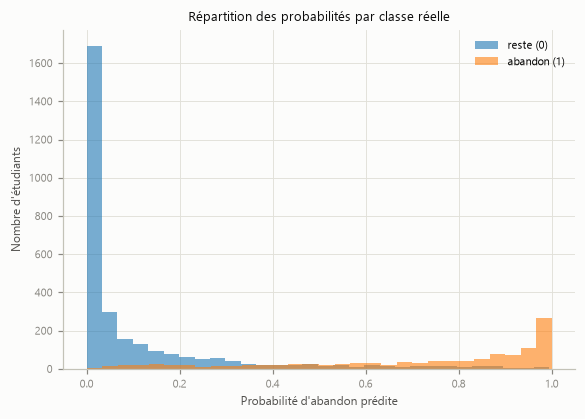

In [25]:
preproc_lineaire = construire_preprocesseur(FEATURES, scale=True)
preproc_arbre = construire_preprocesseur(FEATURES, scale=False)
modeles = families.build_classifiers(
    preproc_linear=preproc_lineaire, preproc_tree=preproc_arbre, seed=SEED
)

proba_baseline = evaluation.oof_proba(modeles["logreg"], X_train, y_train, cv)
m_baseline = evaluation.classification_metrics(y_train, proba_baseline)
display(
    pd.DataFrame(
        {
            "Baseline (LogReg, OOF)": [
                f"{m_baseline[k]:.3f}" for k in ("roc_auc", "pr_auc", "brier")
            ]
        },
        index=pd.Index(["ROC-AUC", "PR-AUC", "Brier"], name="Mesure"),
    )
)
evaluation.plot_score_distribution(y_train, proba_baseline)
plt.show()

### Interprétation

- **La barre est déjà haute** - l'histogramme sépare nettement les deux populations : les décrocheurs se massent vers les probabilités élevées, le reste vers les basses. 
- La **zone de recouvrement** au centre est précisément là où un seuil devra trancher (§9).

## 8.5 Cible principale - Comparaison des familles

On oppose la baseline aux deux modèles à arbres, à **armes égales** (mêmes folds, même préparation, aucune pondération de classe - réglage renvoyé à §9, D10).

> 🔎 **Deux façons de résumer les 5 folds.**
> - Le **tableau** ci-dessous donne la ROC-AUC **par fold** : une AUC calculée séparément sur chacun des 5 folds de validation (~832 étudiants), puis leur **moyenne ± écart-type σ** - le σ dit si l'écart entre familles dépasse le bruit d'un tirage. 
> - Les **courbes** plus bas sont tracées autrement : sur les probabilités *out-of-fold regroupées* (chaque étudiant prédit par le modèle qui l'a mis de côté, soit un seul jeu de 4160 probabilités classées ensemble) - un tracé unique, sans dispersion.

In [26]:
# Comparaison en moyenne par fold de validation (± écart-type pour le critère de départage) :
# un écart de moyenne ne compte que s'il dépasse la dispersion inter-folds.
familles_scores = {}
for nom, pipe in modeles.items():
    auc = evaluation.cv_scores(pipe, X_train, y_train, cv, scoring="roc_auc")
    ap = evaluation.cv_scores(pipe, X_train, y_train, cv, scoring="average_precision")
    brier = -evaluation.cv_scores(pipe, X_train, y_train, cv, scoring="neg_brier_score")
    familles_scores[nom] = {
        "ROC-AUC (moy. folds)": auc.mean(),
        "σ ROC-AUC": auc.std(),
        "PR-AUC (moy. folds)": ap.mean(),
        "Brier (moy. folds)": brier.mean(),
    }
display(pd.DataFrame(familles_scores).T.rename_axis("Famille").round(4))

,ROC-AUC (moy. folds),σ ROC-AUC,PR-AUC (moy. folds),Brier (moy. folds)
Famille,,,,
logreg,0.9475,0.0062,0.8765,0.0825
random_forest,0.9401,0.0069,0.8504,0.0892
xgboost,0.9371,0.0069,0.8471,0.0991


- **La régression logistique mène** sur les trois mesures - meilleur classement (ROC-AUC, PR-AUC) et probabilités les mieux calibrées (Brier le plus bas).
- **Ecart de rang modeste** - elle ne devance la forêt que d'environ un écart-type inter-folds (σ) : le classement seul ne tranche pas. Ce qui départage se lit plus bas, dans la calibration et le sur-apprentissage.

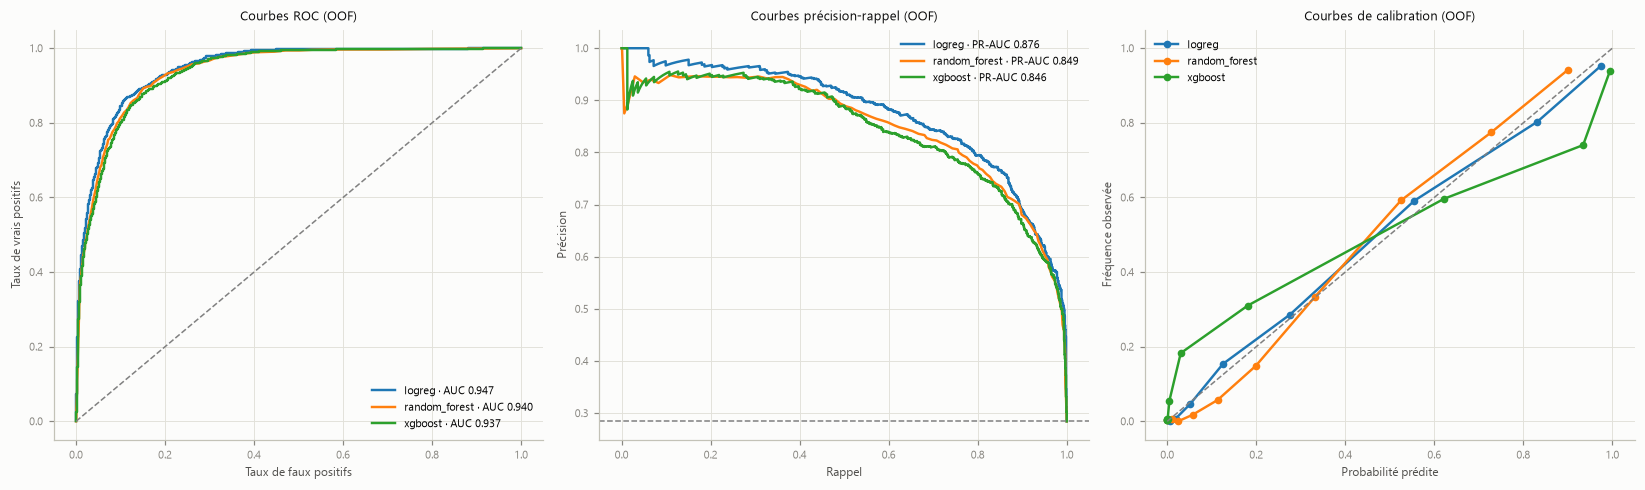

,ROC-AUC (entraînement),ROC-AUC (OOF),écart
Famille,,,
logreg,0.952,0.947,0.005
random_forest,1.000,0.940,0.060
xgboost,1.000,0.937,0.063


In [27]:
# Courbes sur les prédictions OOF regroupées (une courbe tracée sur tous les points).
probas = {nom: evaluation.oof_proba(pipe, X_train, y_train, cv) for nom, pipe in modeles.items()}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
evaluation.plot_roc(y_train, probas, ax=axes[0])
evaluation.plot_pr(y_train, probas, ax=axes[1])
evaluation.plot_calibration(y_train, probas, ax=axes[2])
plt.tight_layout()
plt.show()

# Sur-apprentissage : ROC-AUC en resubstitution (entraînement) vs validation croisée.
diagnostic = (
    pd.DataFrame(
        [
            {"Famille": nom, **evaluation.train_vs_oof(pipe, X_train, y_train, cv)}
            for nom, pipe in modeles.items()
        ]
    )
    .set_index("Famille")
    .rename(columns={"train_roc_auc": "ROC-AUC (entraînement)", "oof_roc_auc": "ROC-AUC (OOF)"})
)
diagnostic["écart"] = diagnostic["ROC-AUC (entraînement)"] - diagnostic["ROC-AUC (OOF)"]
display(diagnostic.round(3))

### Interprétation

- **Courbes** (sur prédictions OOF regroupées) - ROC et précision-rappel confirment le classement ; la régression logistique colle le mieux à la diagonale de calibration.
- **Sur-apprentissage** - la forêt et XGBoost atteignent un score **parfait (1,0) à l'entraînement** mais bien plus bas en validation : elles **mémorisent** les exemples. La régression logistique obtient des scores quasi identiques à l'entraînement et en validation - elle **généralise**, malgré la colinéarité du bloc d'engagement (§6.6) qu'on redoutait pour un linéaire.

## 8.6 Cible principale - Minimisation

Par principe de **minimisation** (ne garder que le nécessaire - art. 5.1.c du RGPD), on cherche à **retirer** des variables plutôt qu'à en ajouter : les trois **leurres** (D11), les trois **proxies socio-économiques** (D14) et les variables **LMS redondantes** (D20). Ces dernières mesurent la même activité (corrélées de 0,80 à 0,92, §6.6) : on n'en garde **qu'une**, `heures_lms_total` - un choix en partie arbitraire, mais `heures_lms_total` n'a **aucun manquant** (argument favorable) et mesure directement un volume d'engagement.

Pour chaque bloc, on mesure ce que son retrait **coûte** - c'est l'**ablation** : on ré-entraîne sans le bloc et on compare au jeu complet. On ne conserve un bloc que si son retrait dégrade **nettement** la détection des décrocheurs.

,n_features,ROC-AUC (OOF),PR-AUC (OOF),Δ ROC-AUC (OOF),Δ PR-AUC (OOF)
scenario,,,,,
complet,24,0.9475,0.8759,0.0000,0.0000
sans leurres,21,0.9489,0.8790,0.0014,0.0032
sans proxies,21,0.9465,0.8734,-0.0009,-0.0025
sans LMS redondantes,22,0.9445,0.8703,-0.0030,-0.0056
minimisé,16,0.9451,0.8712,-0.0024,-0.0047


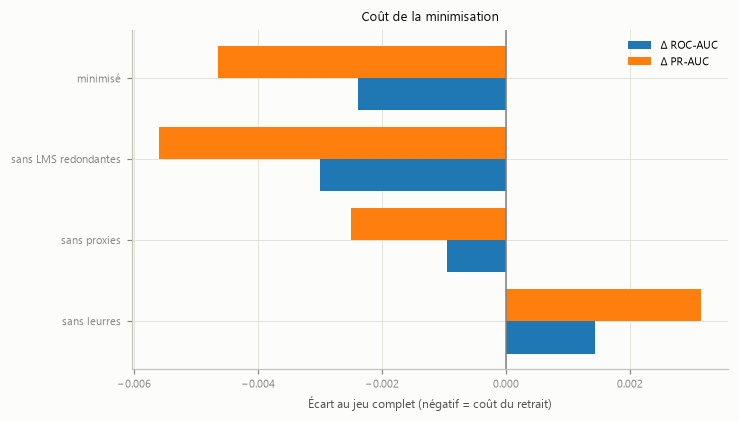

In [28]:
FAMILLE_RETENUE = "logreg"  # verdict de §8.5, porté au journal
blocs = {
    "leurres": ["groupe_td", "couleur_carte_etudiante", "jour_inscription"],
    "proxies": ["etablissement_origine", "heures_travail_remunere_sem", "distance_domicile_km"],
    "LMS redondantes": [
        "connexions_lms_30j",
        "ressources_consultees",
    ],  # heures_lms_total conservée
}


def construire_pipeline_retenu(features):
    """Le pipeline de la famille retenue, préprocesseur restreint à `features` (pour l'ablation)."""
    pl = construire_preprocesseur(features, scale=(FAMILLE_RETENUE == "logreg"))
    pt = construire_preprocesseur(features, scale=False)
    return families.build_classifiers(preproc_linear=pl, preproc_tree=pt, seed=SEED)[
        FAMILLE_RETENUE
    ]


table_ablation = ablation.ablate(construire_pipeline_retenu, X_train, y_train, blocs, cv)
display(
    table_ablation[["n_features", "roc_auc", "pr_auc", "d_roc_auc", "d_pr_auc"]]
    .round(4)
    .rename(
        columns={
            "roc_auc": "ROC-AUC (OOF)",
            "pr_auc": "PR-AUC (OOF)",
            "d_roc_auc": "Δ ROC-AUC (OOF)",
            "d_pr_auc": "Δ PR-AUC (OOF)",
        }
    )
)
evaluation.plot_ablation_cost(table_ablation)
plt.show()

### Interprétation

- **Retirer ne coûte presque rien** - chaque bloc ôté laisse les scores à quelques **millièmes** du jeu complet ; retirer les leurres les **améliore** même légèrement.
- Le jeu **minimisé** (16 variables, tous les blocs retirés) reste à quelques millièmes du complet : la minimisation exigée par le RGPD est **gratuite** en performance.

## 8.7 Cible secondaire — méthode de comparaison

En complément de l'abandon, on prédit la **note finale sur 20** - une régression, menée avec la même méthode qu'en §8.3.

**La baseline** - une régression **Ridge** (linéaire régularisée), simple et interprétable : le point de repère à battre.

**Les familles comparées** - à la baseline s'ajoutent la **forêt aléatoire** et le **gradient boosting**, deux modèles à base d'**arbres de décision** capables de capter des effets non linéaires et des interactions.

**Les prédictions bornées** - une note est comprise entre **0 et 20** ; on borne donc les prédictions à cet intervalle (`clip`). Sans cela, un modèle linéaire comme Ridge peut extrapoler au-dessus de 20 ou sous 0 - ce qui n'a aucun sens pour une note ; les modèles à arbres, eux, y restent naturellement.

**Les mesures** - en points sur 20, indépendantes de tout seuil :

- **MAE** (erreur absolue moyenne) - l'écart typique entre note prédite et note réelle ;
- **RMSE** - même logique, mais pénalise davantage les grosses erreurs ;
- **R²** - part de variance expliquée : 0 = aussi bien que prédire la moyenne, 1 = parfait.

Comparaison sur le train en validation croisée à 5 folds ; la mesure définitive hors échantillon se fera sur le **test scellé** en §12.

## 8.8 Cible secondaire - Baseline

On entraîne la baseline Ridge définie en §8.7 - le niveau à dépasser.

,"Baseline (Ridge, OOF)"
Mesure,
MAE (pts/20),2.455
RMSE (pts/20),3.084
R²,0.676


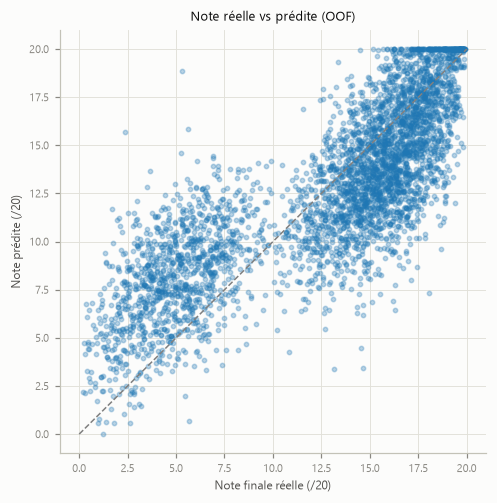

In [29]:
y_moyenne = train_df[CIBLE_REGRESSION]
cv_reg = protocol.make_cv(
    n_splits=5, seed=SEED, stratified=False
)  # cible continue : pas de stratification
regresseurs = families.build_regressors(
    preproc_linear=construire_preprocesseur(FEATURES, scale=True),
    preproc_tree=construire_preprocesseur(FEATURES, scale=False),
    seed=SEED,
)

# Une note est bornée à [0, 20] : on borne les prédictions (un modèle linéaire peut
# extrapoler hors de cet intervalle, ce qui n'a pas de sens pour une note).
pred_ridge = evaluation.oof_pred(regresseurs["ridge"], X_train, y_moyenne, cv_reg).clip(0, 20)
m_ridge = evaluation.regression_metrics(y_moyenne, pred_ridge)
display(
    pd.DataFrame(
        {"Baseline (Ridge, OOF)": [f"{m_ridge[k]:.3f}" for k in ("mae", "rmse", "r2")]},
        index=pd.Index(["MAE (pts/20)", "RMSE (pts/20)", "R²"], name="Mesure"),
    )
)
evaluation.plot_regression_fit(y_moyenne, pred_ridge)
plt.show()

### Interprétation

- La baseline explique déjà une bonne part de la variance (R² lisible ci-dessus) - le nuage réel/prédit suit la diagonale, avec une dispersion résiduelle de quelques points. C'est le niveau que les modèles à arbres doivent battre.

## 8.9  Cible secondaire - Comparaison des familles

On oppose la baseline Ridge aux deux modèles à arbres - mêmes folds, mêmes mesures.

,"MAE (pts/20, OOF)","RMSE (pts/20, OOF)",R² (OOF)
Famille,,,
ridge,2.455,3.084,0.676
random_forest,2.275,3.062,0.680
gradient_boosting,2.196,2.973,0.699


**> Ajustement du meilleur modèle - gradient_boosting**

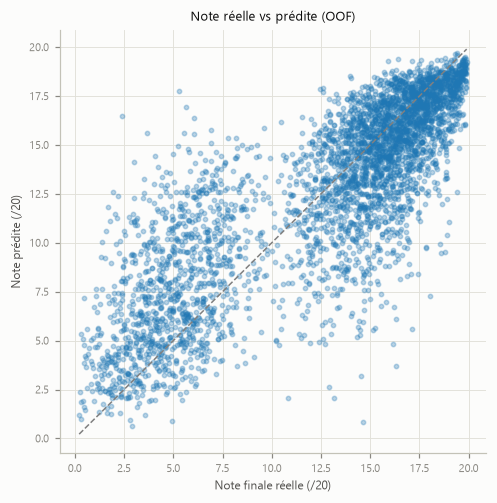

In [30]:
predictions, lignes_reg = {}, []
for nom, pipe in regresseurs.items():
    pred = evaluation.oof_pred(pipe, X_train, y_moyenne, cv_reg).clip(0, 20)  # note bornée [0, 20]
    predictions[nom] = pred
    m = evaluation.regression_metrics(y_moyenne, pred)
    lignes_reg.append(
        {
            "Famille": nom,
            "MAE (pts/20, OOF)": m["mae"],
            "RMSE (pts/20, OOF)": m["rmse"],
            "R² (OOF)": m["r2"],
        }
    )
display(pd.DataFrame(lignes_reg).set_index("Famille").round(3))

meilleure_reg = min(
    predictions, key=lambda n: evaluation.regression_metrics(y_moyenne, predictions[n])["mae"]
)
display(Markdown(f"**> Ajustement du meilleur modèle - {meilleure_reg}**"))
evaluation.plot_regression_fit(y_moyenne, predictions[meilleure_reg])
plt.show()

### Interprétation

- **Le gradient boosting mène** - erreur moyenne d'environ **2,2 points sur 20**, devant Ridge et la forêt. Son nuage réel/prédit se resserre autour de la diagonale.

## 8.10 Cible secondaire - Minimisation

On rejoue donc ici la **même ablation** qu'en §8.6, mais sur la régression - on ne conserve un bloc que si son retrait dégrade nettement la prédiction de la note.

,n_features,"MAE (pts/20, OOF)","RMSE (pts/20, OOF)",R² (OOF),"Δ MAE (pts/20, OOF)","Δ RMSE (pts/20, OOF)"
scenario,,,,,,
complet,24,2.1964,2.9732,0.6986,0.0000,0.0000
sans leurres,21,2.2038,2.9833,0.6965,0.0074,0.0101
sans proxies,21,2.1915,2.9684,0.6995,-0.0049,-0.0048
sans LMS redondantes,22,2.2416,3.0246,0.6880,0.0452,0.0514
minimisé,16,2.2334,3.0179,0.6894,0.0370,0.0447


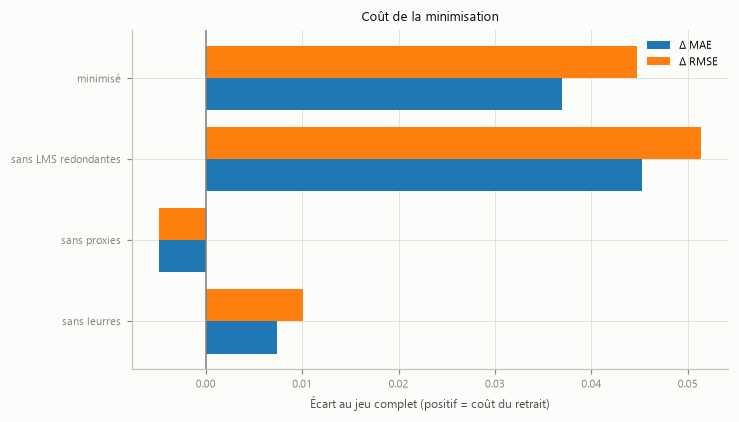

In [31]:
def construire_regresseur_retenu(features):
    """Le régresseur retenu (gradient boosting), préprocesseur restreint à `features`."""
    pt = construire_preprocesseur(features, scale=False)
    return families.build_regressors(preproc_linear=pt, preproc_tree=pt, seed=SEED)[meilleure_reg]


table_ablation_reg = ablation.ablate_regression(
    construire_regresseur_retenu,
    X_train,
    y_moyenne,
    blocs,
    cv_reg,
    postprocess=lambda pred: pred.clip(0, 20),
)  # note bornée [0, 20]
display(
    table_ablation_reg[["n_features", "mae", "rmse", "r2", "d_mae", "d_rmse"]]
    .round(4)
    .rename(
        columns={
            "mae": "MAE (pts/20, OOF)",
            "rmse": "RMSE (pts/20, OOF)",
            "r2": "R² (OOF)",
            "d_mae": "Δ MAE (pts/20, OOF)",
            "d_rmse": "Δ RMSE (pts/20, OOF)",
        }
    )
)
evaluation.plot_ablation_cost(
    table_ablation_reg,
    cols=("d_mae", "d_rmse"),
    labels=("Δ MAE", "Δ RMSE"),
    xlabel="Écart au jeu complet (positif = coût du retrait)",
)
plt.show()

### Interprétation

- **Retirer coûte ici aussi très peu** - le jeu minimisé (16 variables) n'alourdit la MAE que de quelques centièmes de point sur 20 ; les proxies socio-économiques n'apportent quasi rien à la prédiction de la note.
- **Jeu retenu : le minimisé (16 variables)**, le même que pour l'abandon - la minimisation devient cohérente à l'échelle du système, sans coût matériel.

## 8.11 Contraintes opérationnelles et éco-conception

Le choix de la régression logistique n'est pas que statistique, il est aussi **opérationnel et frugal** :

- **léger** - un modèle linéaire s'entraîne et prédit en une fraction de seconde, sans matériel spécialisé ; le ré-entraînement annuel (D06) coûte quasi rien et l'artefact sérialisé (§10) est minuscule face à un ensemble d'arbres ;
- **interprétable** - l'équipe pédagogique peut lire *pourquoi* un étudiant est signalé (SHAP §12), condition d'un accompagnement actionnable plutôt que subi (D05) ;
- **sobre en données** - le jeu minimisé (16 variables) réduit d'autant la collecte, le stockage et la surface RGPD - une éco-conception qui rejoint la minimisation (§8.6).

## 8.12 Choix du modèle

Au terme de la comparaison, les modèles retenus que §9 optimisera (hyperparamètres, seuil) :

| Cible | Modèle retenu | Jeu de variables | Ce qui l'a départagé |
|---|---|---|---|
| **Abandon** (classification) | **Régression logistique** | minimisé - 16 variables | meilleure en validation croisée, la mieux calibrée, la seule à ne pas sur-apprendre, interprétable |
| **Note finale** (régression) | **Gradient boosting** | minimisé - 16 variables | plus faible erreur (~2,2 pts/20) |

## _Journal de bord des décisions_

Chaque choix est argumenté à sa sous-section ; le journal en garde la trace et, s'il y a lieu, l'**alternative écartée**.

1. **[D24] Partition stratifiée 80/20 + validation croisée en 5 folds, test scellé jusqu'à §12.**

2. **[D26 · D27 · D28] Mise en forme des variables** (cf. tableau §8.2) - imputation médiane, `mention_bac` en ordinal, catégories en one-hot à vocabulaire déclaré ; exclusion des cibles, des protégées (D13) et de `date_inscription`.
*Écarté* - Likert en **ordinal** (l'échelle est déjà numérique et régulière) ; **ancienneté** dérivée de `date_inscription` (aucun signal en §6, et contraire à la minimisation).

3. **[D25] Famille retenue pour l'abandon : régression logistique.** Elle devance les arbres en validation croisée (à ~1 σ près), est la mieux calibrée et la seule à ne pas sur-apprendre.
*Écarté* - **HistGB** (même famille que XGBoost, n'ajoute pas une famille distincte) ; le challenger à base d'arbres sera néanmoins re-testé après réglage des hyperparamètres en §9.

4. **[D11 · D14 · D16 · D20 · D23] Jeu de variables retenu : le minimisé (16 variables).** Le coût du retrait est négligeable (quelques millièmes d'AUC, sous la dispersion inter-folds).
*Écarté* - **garder les blocs** pour ce gain minime, sans commune mesure avec le coût RGPD. SHAP §12 confirmera sur le modèle final.

5. **[D29] Note finale : gradient boosting, sur le jeu minimisé (16 variables), toute la promotion.** Même minimisation que l'abandon - coût mesuré négligeable (§8.10), cohérence RGPD à l'échelle du système.
*Écarté* - **restreindre aux non-décrocheurs** : biaiserait la note vers le haut.

# 9. Entraînement, validation et ajustement (sélection du modèle final) — journal de bord [C5]

**Objectif** : optimiser les deux modèles retenus en §8 : régler leurs hyperparamètres, fixer le seuil de décision de l'abandon, vérifier la fiabilité des probabilités - **sur le train seul**. Le test reste scellé jusqu'à §12 : ni réglage, ni seuil, ni calibration ne le regardent.

Le pouvoir discriminant est acquis en §8 (ROC-AUC 0,948 pour l'abandon) ; §9 ne cherche pas à gratter une AUC déjà excellente, mais à s'assurer qu'elle est **fiable** (la calibration, §9.3), puis à en faire une **décision** (le seuil, §9.4). Le réglage des hyperparamètres est conduit pour **démontrer la démarche et prouver** - non supposer - que le modèle est déjà à son plafond.

In [32]:
logging.getLogger("codecarbon").disabled = True

optuna.logging.set_verbosity(optuna.logging.WARNING)

# Jeu minimisé (16 variables) retenu en §8.6 : FEATURES moins les blocs retirés (D11 · D14 · D20).
blocs_flat = [c for bloc in blocs.values() for c in bloc]
FEATURES_MIN = [f for f in FEATURES if f not in blocs_flat]
X_train_min = X_train[FEATURES_MIN]
y_note = y_moyenne  # note /20 (cible secondaire, définie en §8)

display(
    Markdown(
        f"Jeu minimisé : **{len(FEATURES_MIN)}** variables · "
        f"train **{len(X_train_min)}** étudiants · "
        f"réglage sur le train seul, test scellé jusqu'à §12"
    )
)

Jeu minimisé : **16** variables · train **4160** étudiants · réglage sur le train seul, test scellé jusqu'à §12

## 9.1 Cible principale - Déséquilibre de classes

La promotion compte environ **28 % de décrocheurs** - un déséquilibre léger. Deux leviers déplacent le compromis rappel / précision, chacun à un moment différent : **pondérer les classes** (`class_weight="balanced"`) agit *pendant* l'entraînement en pénalisant davantage les erreurs sur la minorité ; **régler le seuil** (§9.4) agit *après*, en abaissant le point de décision sur des probabilités déjà apprises. Comme le seuil sera réglé de toute façon en §9, la seule chose que la pondération pourrait apporter en plus, c'est une **meilleure séparation des deux populations** - et non un simple déplacement du curseur, que le seuil fait déjà.

Or la pondération a un **coût connu d'avance** : en sur-pénalisant la minorité, elle pousse le modèle à sur-annoncer le décrochage, si bien que ses probabilités se retrouvent **gonflées par construction** - une décalibration attendue, pas un effet de bord. On ne peut donc pas la juger sur la seule discrimination ; il faut regarder ce qu'elle fait aux probabilités.

On la met à l'épreuve **contre un témoin non pondéré** (D10), sur les probabilités *out-of-fold* (chaque étudiant prédit par le pli qui l'a mis de côté, §8.5), selon deux critères : la **discrimination, indépendante du seuil** (ROC-AUC, PR-AUC) - dit si pondérer sépare mieux ; et la **calibration** (Brier, diagramme de fiabilité) - dit à quel coût, les probabilités restant fiables ou non.

,ROC-AUC (OOF),PR-AUC (OOF),Brier (OOF)
Témoin (sans pondération),0.9451,0.8712,0.0845
Pondéré (balanced),0.9452,0.8720,0.0948


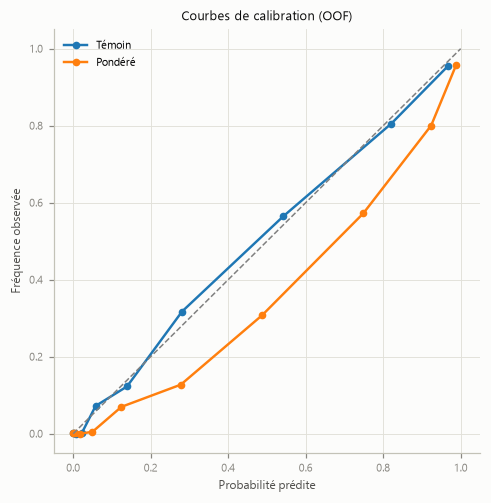

In [33]:
# Deux LogReg identiques au modèle retenu (§8) ; seule diffère la pondération des classes.
logreg_temoin = construire_pipeline_retenu(FEATURES_MIN)
logreg_pondere = construire_pipeline_retenu(FEATURES_MIN).set_params(model__class_weight="balanced")

proba_temoin = evaluation.oof_proba(logreg_temoin, X_train_min, y_train, cv)
proba_pondere = evaluation.oof_proba(logreg_pondere, X_train_min, y_train, cv)

comparaison_poids = pd.DataFrame(
    {
        "Témoin (sans pondération)": evaluation.classification_metrics(y_train, proba_temoin),
        "Pondéré (balanced)": evaluation.classification_metrics(y_train, proba_pondere),
    }
).T.rename(columns={"roc_auc": "ROC-AUC (OOF)", "pr_auc": "PR-AUC (OOF)", "brier": "Brier (OOF)"})
display(comparaison_poids.round(4))

evaluation.plot_calibration(y_train, {"Témoin": proba_temoin, "Pondéré": proba_pondere})
plt.show()

### Interprétation

- **Discrimination inchangée** - ROC-AUC (0,9451 vs 0,9452) et PR-AUC (0,8712 vs 0,8720) sont identiques à quelques dix-millièmes : pondérer ne fait pas mieux *voir* le modèle.
- **Calibration dégradée** - le Brier passe de **0,0845 à 0,0948** et la courbe pondérée s'écarte de la diagonale : `balanced` sur-annonce le décrochage, gonflant les probabilités de la classe minoritaire.
- Pondérer ne fait donc que **déplacer le point de fonctionnement** - exactement ce que le seuil (§9.4) règle de façon contrôlée, sans abîmer les probabilités dont il a besoin : le déséquilibre se traite au seuil, non par pondération (D10).

**Conclusion** : La pondération via `class_weight="balanced"` n'est pas pertinente

## 9.2 Optimisation des hyperparamètres

On règle chaque finaliste **sur le train seul**, aux **mêmes plis et métrique qu'en §8** (aucune fuite : le préprocesseur est refité dans le pipeline à chaque pli). L'outil est choisi selon la taille de l'espace de recherche - c'est là qu'est l'éco-conception :

- **Abandon - régression logistique.** Espace minuscule (`C`, `penalty`) : une **recherche exhaustive** (`GridSearchCV`) suffit, déterministe et quasi gratuite - Optuna serait de la sur-ingénierie. Le **challenger à base d'arbres est re-testé après réglage** (D25) pour contrôler si la forêt aléatoire optimisée repasse devant la LogReg.

- **Note finale - gradient boosting.** Espace large : une recherche **Optuna** (échantillonnage TPE) bornée par un budget (`n_trials` + `timeout`), avec *pruning* (essai mal parti abandonné tôt) et *early stopping* (arbres stoppés quand la validation plafonne). On compare trois régimes - **base** (non réglé), **frugal**, **lourd** - au gain de MAE **et** au coût carbone.

#### Cible principale - régression logistique

In [34]:
# class_weight figé par le verdict de §9.1 (None) ; la pénalité reste L2 (défaut, adaptée à un
# modèle dense à 16 variables) ; on règle la seule force de régularisation C.
CLASS_WEIGHT = None
grille_logreg = {"model__C": [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}
base_logreg = construire_pipeline_retenu(FEATURES_MIN).set_params(model__class_weight=CLASS_WEIGHT)
recherche_logreg = GridSearchCV(base_logreg, grille_logreg, scoring="roc_auc", cv=cv, n_jobs=-1)
recherche_logreg.fit(X_train_min, y_train)

logreg_final = recherche_logreg.best_estimator_
auc_base = evaluation.cv_scores(base_logreg, X_train_min, y_train, cv, scoring="roc_auc").mean()
auc_regle = recherche_logreg.best_score_
display(
    Markdown(
        f"**LogReg** - grille de **{len(grille_logreg['model__C'])}** valeurs de C · "
        f"ROC-AUC base **{auc_base:.4f}** → réglée **{auc_regle:.4f}** · "
        f"HP retenu : `C={recherche_logreg.best_params_['model__C']}` (pénalité L2, défaut)"
    )
)

**LogReg** - grille de **7** valeurs de C · ROC-AUC base **0.9453** → réglée **0.9457** · HP retenu : `C=0.1` (pénalité L2, défaut)

### Interprétation

- **Plafond confirmé** - le réglage ne gagne que **4 dix-millièmes** de ROC-AUC (0,9453 → 0,9457) : la régression logistique par défaut était déjà à son maximum. Le `C=0,1` retenu régularise un peu plus fort que le défaut (`C=1`), cohérent avec un modèle dense à 16 variables.

#### Challenger - forêt aléatoire re-testée

En §8, la LogReg devançait les arbres à hyperparamètres par défaut, à environ un écart-type près (D25). On règle donc la **forêt aléatoire** sur le jeu minimisé - même budget Optuna - pour vérifier qu'elle ne repasse pas devant après réglage.

In [35]:
# Forêt aléatoire réglée (Optuna frugal) : la LogReg réglée garde-t-elle l'avantage ? (D25)
def build_rf(params):
    """Construit la forêt aléatoire (jeu minimisé) selon les hyperparamètres proposés."""
    pt = construire_preprocesseur(FEATURES_MIN, scale=False)
    pipe = families.build_classifiers(preproc_linear=pt, preproc_tree=pt, seed=SEED)[
        "random_forest"
    ]
    return pipe.set_params(**{f"model__{k}": v for k, v in params.items()})


def suggest_rf(trial):
    """Espace de recherche de la forêt aléatoire (Optuna)."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 200, 500, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
    }


def regler_rf():
    """Règle la forêt (Optuna frugal) ; ne renvoie que des scalaires (cache §9)."""
    best, etude = tuning.optuna_search(
        build_rf,
        suggest_rf,
        X_train_min,
        y_train,
        cv,
        scoring="roc_auc",
        n_trials=20,
        timeout=120,
        seed=SEED,
    )
    return {
        "best_params": best,
        "essais": len(etude.trials),
        "ratio_elagues": tuning.pruned_ratio(etude),
    }


rf = tuning.cached_search(CACHE_REGLAGE, "foret", regler_rf, use_cache=REGLAGE_DEPUIS_CACHE)
auc_rf = evaluation.cv_scores(
    build_rf(rf["best_params"]), X_train_min, y_train, cv, scoring="roc_auc"
).mean()
verdict_rf = (
    "la LogReg conserve l'avantage" if auc_regle >= auc_rf else "la forêt dépasse la LogReg"
)
display(
    Markdown(
        f"**Forêt réglée** ({rf['essais']} essais, {rf['ratio_elagues']:.0%} élagués) - "
        f"ROC-AUC **{auc_rf:.4f}** · LogReg réglée **{auc_regle:.4f}** → **{verdict_rf}**"
    )
)

**Forêt réglée** (20 essais, 0% élagués) - ROC-AUC **0.9397** · LogReg réglée **0.9457** → **la LogReg conserve l'avantage**

##### Interprétation

- **D25 confirmée** - même réglée (20 essais), la forêt aléatoire plafonne à **0,9397**, sous la régression logistique réglée (**0,9457**) : le challenger à base d'arbres ne repasse pas devant après optimisation. La famille retenue en §8 tient.

#### Cible secondaire - gradient boosting

On règle le **gradient boosting** (D29) de la note, en comparant trois régimes de recherche - **base** (défauts §8), **frugal** (20 essais), **lourd** (150 essais) - chacun sous mesure d'empreinte carbone. L'objet n'est pas seulement de trouver les meilleurs hyperparamètres, mais de **mettre en regard le gain de performance et le coût carbone** de la recherche.

,essais,"MAE (pts/20, OOF)",durée (s),CO₂ (g)
Régime,,,,
base (défauts §8),0,2.233,0.0,0.000
Optuna frugal,20,2.221,53.4,0.038
Optuna lourd,150,2.208,345.8,0.247


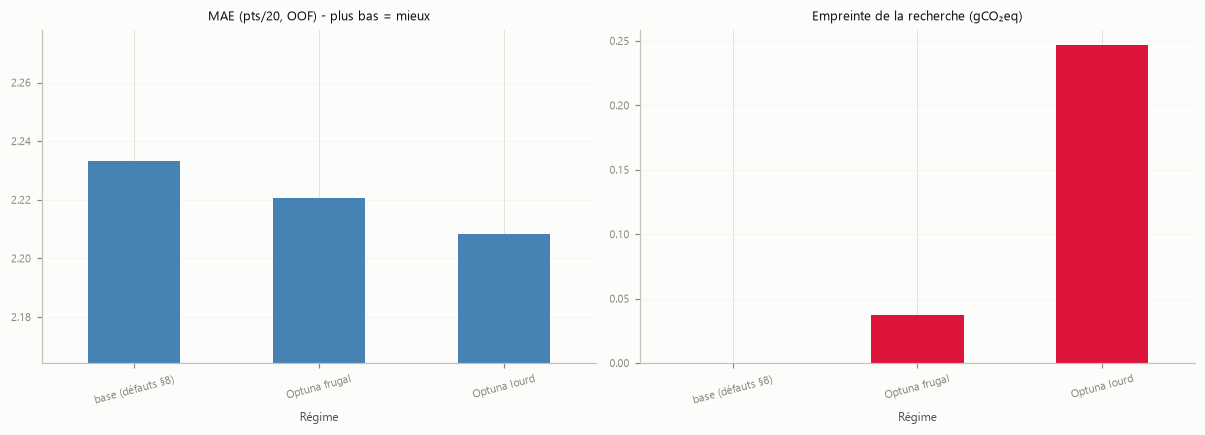

Régime retenu pour la note : **base (défauts §8)** - meilleure MAE à moins de 0.03 pt/20, le plus sobre

In [36]:
from codecarbon import OfflineEmissionsTracker
from sklearn.base import clone

preproc_tree_reg = construire_preprocesseur(FEATURES_MIN, scale=False)
# base = défauts §8 (D29), sans early stopping - c'est le point de référence à battre.
base_gb = families.build_regressors(
    preproc_linear=preproc_tree_reg, preproc_tree=preproc_tree_reg, seed=SEED
)["gradient_boosting"]


def build_gb(params):
    """GB à régler : défauts §8 + early stopping (stoppé quand la validation plafonne)."""
    pipe = families.build_regressors(
        preproc_linear=preproc_tree_reg, preproc_tree=preproc_tree_reg, seed=SEED
    )["gradient_boosting"]
    return pipe.set_params(
        model__n_iter_no_change=10,
        model__validation_fraction=0.1,
        **{f"model__{k}": v for k, v in params.items()},
    )


def suggest_gb(trial):
    """Espace de recherche du gradient boosting (Optuna)."""
    return {
        "n_estimators": trial.suggest_int("n_estimators", 100, 400, step=50),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 4),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 50),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
    }


def mae_oof(pipe):
    """MAE out-of-fold, prédictions bornées [0, 20] (contrainte de domaine, §8.7)."""
    pred = evaluation.oof_pred(pipe, X_train_min, y_note, cv_reg).clip(0, 20)
    return evaluation.regression_metrics(y_note, pred)["mae"]


def regler_gb(n_trials, timeout):
    """Règle le GB sous budget borné + mesure l'empreinte ; renvoie des scalaires (cache §9)."""
    suivi = OfflineEmissionsTracker(
        country_iso_code="FRA", save_to_file=False, log_level="error", measure_power_secs=3600
    )
    logging.getLogger("codecarbon").disabled = True  # coupe le journal périodique du tracker
    suivi.start()
    best, etude = tuning.optuna_search(
        build_gb,
        suggest_gb,
        X_train_min,
        y_note,
        cv_reg,
        scoring="neg_mean_absolute_error",
        n_trials=n_trials,
        timeout=timeout,
        seed=SEED,
    )
    suivi.stop()
    donnees = suivi.final_emissions_data
    return {
        "params": best,
        "essais": len(etude.trials),
        "duree_s": donnees.duration,
        "co2_g": donnees.emissions * 1000,
    }


# Réglage caché (D30) : un run complet mesure et persiste, un run rapide recharge le cache.
gb_frugal = tuning.cached_search(
    CACHE_REGLAGE, "gb_frugal", lambda: regler_gb(20, 120), use_cache=REGLAGE_DEPUIS_CACHE
)
gb_lourd = tuning.cached_search(
    CACHE_REGLAGE, "gb_lourd", lambda: regler_gb(150, 420), use_cache=REGLAGE_DEPUIS_CACHE
)
best_frugal, best_lourd = gb_frugal["params"], gb_lourd["params"]

mae_base, mae_frugal, mae_lourd = (
    mae_oof(base_gb),
    mae_oof(build_gb(best_frugal)),
    mae_oof(build_gb(best_lourd)),
)
recap_gb = pd.DataFrame(
    [
        {
            "Régime": "base (défauts §8)",
            "essais": 0,
            "MAE (pts/20, OOF)": mae_base,
            "durée (s)": 0.0,
            "CO₂ (g)": 0.0,
        },
        {
            "Régime": "Optuna frugal",
            "essais": gb_frugal["essais"],
            "MAE (pts/20, OOF)": mae_frugal,
            "durée (s)": gb_frugal["duree_s"],
            "CO₂ (g)": gb_frugal["co2_g"],
        },
        {
            "Régime": "Optuna lourd",
            "essais": gb_lourd["essais"],
            "MAE (pts/20, OOF)": mae_lourd,
            "durée (s)": gb_lourd["duree_s"],
            "CO₂ (g)": gb_lourd["co2_g"],
        },
    ]
).set_index("Régime")
display(recap_gb.round({"MAE (pts/20, OOF)": 3, "durée (s)": 1, "CO₂ (g)": 3}))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
recap_gb["MAE (pts/20, OOF)"].plot.bar(ax=a1, color="steelblue")
a1.set_title("MAE (pts/20, OOF) - plus bas = mieux")
a1.set_ylim(recap_gb["MAE (pts/20, OOF)"].min() * 0.98, recap_gb["MAE (pts/20, OOF)"].max() * 1.02)
recap_gb["CO₂ (g)"].plot.bar(ax=a2, color="crimson")
a2.set_title("Empreinte de la recherche (gCO₂eq)")
for a in (a1, a2):
    a.tick_params(axis="x", rotation=15)
    a.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# Éco-conception : à MAE équivalente (< 0,03 pt/20, ~1 %), on retient le régime le plus sobre.
EPS = 0.03
meilleure = min(mae_base, mae_frugal, mae_lourd)
if mae_base <= meilleure + EPS:
    regime_note, gb_regle, best_note = "base (défauts §8)", base_gb, {}
elif mae_frugal <= meilleure + EPS:
    regime_note, gb_regle, best_note = "Optuna frugal", build_gb(best_frugal), best_frugal
else:
    regime_note, gb_regle, best_note = "Optuna lourd", build_gb(best_lourd), best_lourd
display(
    Markdown(
        f"Régime retenu pour la note : **{regime_note}** - "
        f"meilleure MAE à moins de {EPS} pt/20, le plus sobre"
    )
)

### Interprétation

- **Gain marginal** - la recherche lourde (150 essais) n'améliore la MAE que de **0,025 pt/20** sur la base non réglée (2,233 → 2,208), soit ~1 %, quand la frugale (20 essais) en capte déjà l'essentiel (2,221).
- **Coût carbone disproportionné** - ce gain coûte **0,247 g** de CO₂ (346 s) au régime lourd contre **0,038 g** (53 s) au frugal, pour un écart de MAE de seulement 0,013 pt/20 entre les deux.
- Sous un seuil de matérialité de **0,03 pt/20**, l'écart est négligeable : on retient la **base non réglée**, la plus sobre. Le réglage aura servi à *prouver* le plafond, non à le déplacer.

## 9.3 Cible principale - Calibration

Avant de transformer la probabilité en décision (le seuil, §9.4), on s'assure qu'elle est **fiable** : une proba de 0,30 doit correspondre à environ 30 % de décrochage observé. La §8.5 montrait déjà la régression logistique comme la mieux calibrée (Brier le plus bas) ; on **vérifie** ici que le modèle réglé le reste, et on teste un **recalibrage** isotonic - qu'on ne conservera que s'il **baisse le Brier**. Calibrer d'abord garantit que le seuil de §9.4 sera posé sur des probabilités dignes de confiance.

Brier - modèle réglé **0.0841** · recalibré isotonic **0.0842** → **recalibrage sans gain, écarté**

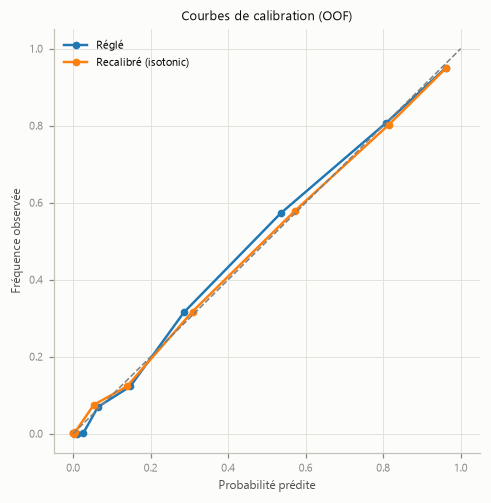

In [37]:
from sklearn.calibration import CalibratedClassifierCV

# Probabilités OOF du modèle réglé - base de la calibration ici, et du seuil en §9.4.
proba_logreg = evaluation.oof_proba(logreg_final, X_train_min, y_train, cv)

# Recalibrage isotonic appris en validation croisée interne (sans fuite) ; comparé au modèle réglé.
logreg_calibre = CalibratedClassifierCV(logreg_final, method="isotonic", cv=cv)
proba_calibre = evaluation.oof_proba(logreg_calibre, X_train_min, y_train, cv)

brier_brut = evaluation.classification_metrics(y_train, proba_logreg)["brier"]
brier_cal = evaluation.classification_metrics(y_train, proba_calibre)["brier"]
verdict_cal = "recalibrage sans gain, écarté" if brier_cal >= brier_brut else "recalibrage retenu"
display(
    Markdown(
        f"Brier - modèle réglé **{brier_brut:.4f}** · "
        f"recalibré isotonic **{brier_cal:.4f}** → **{verdict_cal}**"
    )
)

evaluation.plot_calibration(y_train, {"Réglé": proba_logreg, "Recalibré (isotonic)": proba_calibre})
plt.show()

### Interprétation

- **Déjà calibrée** - le recalibrage isotonic laisse le Brier quasi inchangé (**0,0841 → 0,0842**) et les deux courbes se superposent sur la diagonale : la régression logistique produit des probabilités fiables sans retouche (confirmé depuis §8.5). Recalibrage écarté.

## 9.4 Cible principale - Seuil de décision

Le modèle rend une **probabilité** (jugée fiable en §9.3) mais décider « à risque / pas à risque » exige un **seuil**. 

Le seuil par défaut de 0,5 minimise le nombre d'erreurs *en supposant qu'un faux négatif coûte autant qu'un faux positif* - or ici **rater un décrocheur (FN) coûte bien plus qu'une alerte à tort (FP)** (D03). Il faut donc un seuil plus bas.

Faute d'un coût métier chiffré (l'énoncé ne le fournit pas et il est complexe de l'estimer), le seuil ne se calcule pas : il se **déclare** par une politique lisible, appliquée aux probabilités *out-of-fold*. La table ci-dessous donne, pour chaque seuil, le **nombre d'étudiants à accompagner** (`n_alertes`), sa part de la promotion, et l'arbitrage rappel / précision. L'outil final (§10) exposera deux politiques : un **plancher de rappel** (« attraper au moins R % des décrocheurs ») et une **capacité** (« accompagner N étudiants »).

> **Comment lire la table** (noms techniques, sens dans notre cas d'usage) :  
    - `seuil` - probabilité au-delà de laquelle l'étudiant est **signalé à risque**.  
    - `rappel` - part des décrocheurs **effectivement signalés** : le levier qu'on veut haut, car rater un décrocheur (FN) coûte plus qu'alerter à tort (D03).  
    - `precision` - part des **signalés qui décrochent vraiment** : mesure les alertes à tort (précision basse = beaucoup d'étudiants dérangés pour rien et risque du marquage).  
    - `f2` - synthèse rappel / précision **pondérant le rappel 2× la précision**, cohérente avec l'asymétrie FN >> FP (un F1 les pèserait à parts égales, à contre-emploi ici).  
    - `n_alertes` - nombre d'étudiants signalés = **accompagnements à mener** (vrais et faux positifs confondus, c'est la charge réelle).  
    - `tp` - parmi eux, les **décrocheurs réellement attrapés**.  
    - `n_FN` - décrocheurs **manqués** : le coût qu'on cherche à minimiser.  
    - `pct_promo` - **part de la promotion** signalée (`n_alertes` / effectif).  

In [38]:
# proba_logreg (probabilités OOF du modèle réglé) est calculé en §9.3.
table_seuils = threshold.threshold_table(y_train, proba_logreg)

# Noms techniques conservés (leur sens : légende ci-dessus) ; taux arrondis à 3 décimales.
vue = table_seuils.assign(
    rappel=table_seuils["rappel"].round(3),
    precision=table_seuils["precision"].round(3),
    f2=table_seuils["f2"].round(3),
    pct_promo=table_seuils["pct_promo"].round(3),
)[["rappel", "precision", "f2", "n_alertes", "tp", "n_FN", "pct_promo"]]
display(vue)

,rappel,precision,f2,n_alertes,tp,n_FN,pct_promo
seuil,,,,,,,
0.05,0.994,0.496,0.828,2373,1176,7,0.570
0.10,0.972,0.559,0.847,2059,1150,33,0.495
0.15,0.954,0.610,0.857,1850,1128,55,0.445
0.20,0.931,0.660,0.860,1669,1101,82,0.401
0.25,0.893,0.694,0.845,1524,1057,126,0.366
0.30,0.867,0.725,0.835,1415,1026,157,0.340
0.35,0.841,0.756,0.823,1316,995,188,0.316
0.40,0.816,0.781,0.808,1236,965,218,0.297
0.45,0.778,0.798,0.782,1153,920,263,0.277


### Interprétation

- **0,5 est trop élevé ici** - au seuil par défaut, le rappel n'est que de **0,747** : près de 300 décrocheurs (n_FN = 299) passeraient inaperçus, inacceptable quand un faux négatif coûte bien plus qu'une alerte à tort (D03).
- **Le rappel se paie en volume** - abaisser le seuil remonte le rappel mais élargit les alertes signalées.

**Conclusion** : Faute d'un coût métier chiffrable, le seuil ne se *calcule* pas : on le **déclare** par un objectif de rappel - **détecter 80 % des décrocheurs** (défaut de travail, D04). Cet objectif place le seuil autour de **0,42** et signale **un peu moins de 30 % de la cohorte** (cf. arbitrage ci-dessous) - un choix assumé et défendable, non arbitraire.

Rappel ≥ 80 % → seuil **0.42**, **29.0 %** de la cohorte signalée · rappel 100 % → seuil **0.00**, **92.0 %** signalée (attraper *tous* les décrocheurs coûte la moitié de la promo)

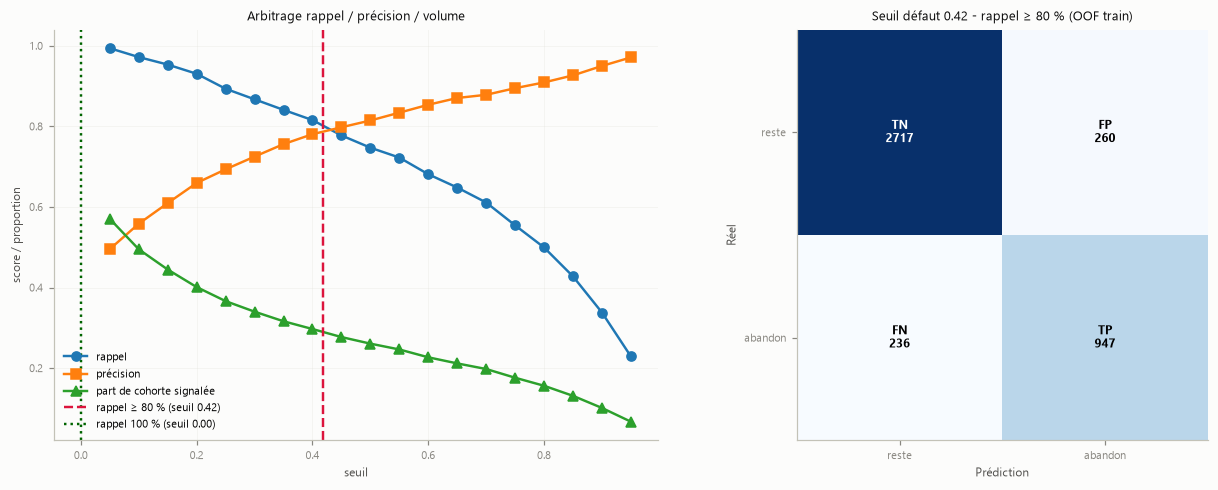

In [39]:
# Deux points de fonctionnement : plancher de rappel 80 % (défaut) et rappel 100 % (borne haute).
SEUIL_DEFAUT = threshold.pick_threshold(y_train, proba_logreg, recall_target=0.80)
SEUIL_100 = threshold.pick_threshold(y_train, proba_logreg, recall_target=1.0)
pct_defaut = (proba_logreg >= SEUIL_DEFAUT).mean() * 100
pct_100 = (proba_logreg >= SEUIL_100).mean() * 100
display(
    Markdown(
        f"Rappel ≥ 80 % → seuil **{SEUIL_DEFAUT:.2f}**, "
        f"**{pct_defaut:.1f} %** de la cohorte signalée · "
        f"rappel 100 % → seuil **{SEUIL_100:.2f}**, **{pct_100:.1f} %** signalée "
        f"(attraper *tous* les décrocheurs coûte la moitié de la promo)"
    )
)

fig, (ax_courbe, ax_mc) = plt.subplots(1, 2, figsize=(12, 4.5))

# Arbitrage : rappel, précision et part de cohorte signalée selon le seuil.
ax_courbe.plot(table_seuils.index, table_seuils["rappel"], marker="o", label="rappel")
ax_courbe.plot(table_seuils.index, table_seuils["precision"], marker="s", label="précision")
ax_courbe.plot(
    table_seuils.index, table_seuils["pct_promo"], marker="^", label="part de cohorte signalée"
)
ax_courbe.axvline(
    SEUIL_DEFAUT, color="crimson", ls="--", label=f"rappel ≥ 80 % (seuil {SEUIL_DEFAUT:.2f})"
)
ax_courbe.axvline(
    SEUIL_100, color="darkgreen", ls=":", label=f"rappel 100 % (seuil {SEUIL_100:.2f})"
)
ax_courbe.set(
    xlabel="seuil", ylabel="score / proportion", title="Arbitrage rappel / précision / volume"
)
ax_courbe.legend()
ax_courbe.grid(alpha=0.3)

# Matrice de confusion au point de fonctionnement par défaut - OOF train, test scellé jusqu'en §12.
evaluation.plot_confusion(
    y_train,
    proba_logreg,
    SEUIL_DEFAUT,
    ax=ax_mc,
    title=f"Seuil défaut {SEUIL_DEFAUT:.2f} - rappel ≥ 80 % (OOF train)",
)
plt.tight_layout()
plt.show()

## 9.5 Modèles finaux

On fige les deux modèles éprouvés : **refit sur tout le train** avec les hyperparamètres retenus, `random_state` fixés, versions loguées - prêts pour la sérialisation en §10. La note (gradient boosting) n'a ni seuil ni calibration : elle rend directement une valeur bornée à [0, 20].

In [40]:
import sklearn

# Refit sur tout le train (le préprocesseur se ré-ajuste sur l'ensemble).
modele_abandon = logreg_final  # déjà refité sur le train entier par GridSearchCV
modele_note = clone(gb_regle).fit(X_train_min, y_note)

hp_note = (
    "défauts §8"
    if not best_note
    else ", ".join(
        f"{k}={round(v, 4) if isinstance(v, float) else v}" for k, v in best_note.items()
    )
)
recap_final = pd.DataFrame(
    {
        "Cible": ["abandon (probabilité)", "moyenne_finale (/20)"],
        "Modèle": ["régression logistique", f"gradient boosting - {regime_note}"],
        "Hyperparamètres retenus": [
            f"C={recherche_logreg.best_params_['model__C']}, "
            f"penalty=L2 (défaut), class_weight={CLASS_WEIGHT}",
            hp_note,
        ],
        "Point de fonctionnement": [
            f"seuil {SEUIL_DEFAUT:.2f} (rappel ≥ 80 %)",
            "sortie bornée [0, 20]",
        ],
    }
).set_index("Cible")
display(recap_final)

versions = pd.DataFrame(
    {"Version": [sklearn.__version__, optuna.__version__, np.__version__, pd.__version__]},
    index=pd.Index(["scikit-learn", "optuna", "numpy", "pandas"], name="Bibliothèque"),
)
display(versions)

,Modèle,Hyperparamètres retenus,Point de fonctionnement
Cible,,,
abandon (probabilité),régression logistique,"C=0.1, penalty=L2 (défaut), class_...",seuil 0.42 (rappel ≥ 80 %)
moyenne_finale (/20),gradient boosting - base (défauts §8),défauts §8,"sortie bornée [0, 20]"


,Version
Bibliothèque,
scikit-learn,1.9.0
optuna,4.9.0
numpy,2.3.5
pandas,3.0.3


**Conclusion** : 

- **Modèles reproductibles** - hyperparamètres et versions des bibliothèques tracés (tableaux ci-dessus), `random_state` fixés partout.

✅ Modèles finaux entraînés - régression logistique (abandon) · gradient boosting (note) - prêts pour §10

## _Journal de bord des décisions_

Chaque choix est argumenté à sa sous-section ; le journal en garde la trace et, s'il y a lieu, l'**alternative écartée**.

1. **[D10] Pas de pondération de classe.** À armes égales, `class_weight="balanced"` laisse la discrimination inchangée (ROC-AUC 0,945, PR-AUC 0,87) mais dégrade la calibration (Brier 0,0845 → 0,0948) : le déséquilibre léger (~28 %) se traite au seuil (§9.4), non par pondération.
*Écarté* - **`balanced`** (déplace le point de fonctionnement au prix des probabilités) et **SMOTE** (sur-échantillonnage superflu à ce niveau de déséquilibre, et déformant).

2. **[D30] Réglage des hyperparamètres dosé selon l'espace, sous budget borné.** Régression logistique par grille exhaustive (`C=0,1`, L2) ; gradient boosting par Optuna borné (20/150 essais, *pruning* + *early stopping*), empreinte carbone mesurée. Pour la note, la **base non réglée est conservée** : le réglage lourd ne gagne que 0,025 pt/20 (~1 %) pour ~7× le carbone du frugal, sous le seuil de matérialité de 0,03 pt/20.
*Écarté* - **Optuna pour la LogReg** (sur-ingénierie sur 7 valeurs de `C`) ; **grille pour le GB** (explosion combinatoire) ; **régime de réglage lourd** (gain non matériel, coût carbone disproportionné).

3. **[D25] Famille de l'abandon confirmée après réglage : régression logistique.** Réglée, la forêt aléatoire plafonne à 0,9397, sous la régression logistique réglée (0,9457) : le challenger à base d'arbres ne repasse pas devant.
*Écarté* - **forêt aléatoire réglée** (reste en deçà, et sur-ajuste - §8.5).

4. **[D31] Pas de recalibrage des probabilités.** Le recalibrage isotonic laisse le Brier quasi inchangé (0,0841 → 0,0842) : la régression logistique est déjà fiable (§8.5).
*Écarté* - **recalibrage isotonic / Platt** (sans gain mesuré).

5. **[D04] Seuil de l'abandon : plancher de rappel de 80 % (défaut de travail, à valider).** Faute de coût métier chiffré, le seuil se déclare par une politique : à rappel ≥ 80 % il tombe à 0,42 et signale 29 % de la promotion. Le modèle expose la probabilité ; le seuil reste externe (D15) et configurable - plancher de rappel ou capacité d'accompagnement.
*À valider en relecture* - le choix de la politique (rappel visé vs nombre de places) fixe la matrice de confusion évaluée en §12 (cf. TODO §9.4).

# 10. Implémentation et mise en exploitation (déploiement, exemple d’usage) — journal de bord [C6]

**Objectif** : figer l'artefact déployable issu du §9 - les deux pipelines et la fiche qui les décrit -, publier son contrat d'entrée/sortie, et prouver son usage par un `predict()` exécuté.

> 🔧 **Comment je m'y prends** - je sérialise le modèle final tel quel (préprocesseur inclus) avec une *fiche* de service (typage, thèmes, seuil, référence de dérive) ; le **contrat d'entrée**, lui, est un schéma typé publié par l'API (§10.3). Le service décrit en §11 relit ces artefacts, sans jamais réapprendre.


## 10.1 La fiche du modèle

La fiche accompagne les pipelines : elle porte le typage (pour la dérive), les **thèmes** d'explicabilité, le **seuil** et les seuils de dérive (surchargeables, D38), et la **distribution de référence**. Le contrat d'entrée, lui, est le schéma typé de l'API (§10.3). Seuls les thèmes sont déclarés ici ; le reste est dérivé de ce que le §9 a produit.


In [41]:
# --- Faits du modèle entraîné (dérivés de ce que le §9 a produit) ---
model_features = list(modele_abandon.feature_names_in_)  # ordre d'entraînement
derivees = [c for c in faits_gold.derived if c in model_features]  # calculées par le service (§7)
numeriques_fiche = [c for c in NUMERIQUES if c in model_features]
categorielles_fiche = [c for c in ORDINALES + NOMINALES if c in model_features]

# Thèmes d'explicabilité : DÉCLARÉS ici (variable -> thème), défendus à l'oral.
THEMES = {
    "taux_presence_pct": "assiduité",
    "nb_devoirs_total": "assiduité",
    "nb_devoirs_rendus": "assiduité",
    "retards_rendus": "assiduité",
    "taux_rendu": "assiduité",
    "ratio_retards": "assiduité",
    "heures_lms_total": "engagement",
    "messages_forum": "engagement",
    "motivation": "ressenti",
    "satisfaction": "ressenti",
    "sentiment_appartenance": "ressenti",
    "age": "parcours",
    "nb_ue_total": "parcours",
    "mention_bac": "parcours",
    "filiere": "parcours",
    "bac_type": "parcours",
}
themes = {c: THEMES[c] for c in model_features if c in THEMES}

# La fiche ne porte que ce qu'un schéma d'entrée ne sait pas exprimer : typage pour la dérive,
# thèmes, seuil et seuils de dérive (surchargeables), distribution de référence.
fiche = ServiceContract(
    facts=ModelFacts(
        version="1.0.0",
        numeric=tuple(numeriques_fiche),
        categorical=tuple(categorielles_fiche),
        themes=themes,
        drift_reference=train_df[model_features].copy(),
    ),
    defaults=OperationalDefaults(
        threshold=float(SEUIL_DEFAUT),
        drift_surveillance=0.10,
        drift_alerte=0.25,
        drift_effectif_min=200,
    ),
)
fiche.validate()

ref_fiche = fiche.facts.drift_reference  # instantané du train scellé dans la fiche

recap = pd.DataFrame(
    {
        "Valeur": [
            fiche.facts.version,
            f"{len(numeriques_fiche)} numériques · {len(categorielles_fiche)} catégorielles",
            f"{len(themes)} variables → {len(set(themes.values()))} thèmes",
            f"seuil {fiche.defaults.threshold:.2f} · dérive "
            f"{fiche.defaults.drift_surveillance:.2f}/{fiche.defaults.drift_alerte:.2f}",
            f"{len(ref_fiche)} lignes × {ref_fiche.shape[1]} variables",  # type: ignore
        ]
    },
    index=pd.Index(
        ["Version", "Typage (dérive)", "Thèmes", "Exploitation", "Réf. dérive"],
        name="Fiche du modèle",
    ),
)
display(recap)

,Valeur
Fiche du modèle,
Version,1.0.0
Typage (dérive),13 numériques · 3 catégorielles
Thèmes,16 variables → 4 thèmes
Exploitation,seuil 0.42 · dérive 0.10/0.25
Réf. dérive,4160 lignes × 16 variables


- **La fiche est le descripteur de service** : typage, thèmes, seuil et seuils de dérive, distribution de référence. Le contrat d'entrée (colonnes, bornes, modalités) est porté par `schemas.PredictEtudiantForm` (§10.3).
- **Deux natures** (D38) : faits immuables (typage, thèmes, référence) et paramètres surchargeables en exploitation (seuil, seuils de dérive), sans réentraîner.
- **Distribution de référence scellée** : le train du split §8, pour mesurer la dérive d'une campagne (§13).


## 10.2 Sérialisation de l'artefact déployable

`save_bundle` écrit trois fichiers et **refuse d'écrire** une fiche incohérente (seuil hors [0, 1], seuils de dérive désordonnés). L'empreinte de chaque fichier trace la version de l'artefact ; celle du jeu de référence, la version des **données** scellées.


In [ ]:
store.save_bundle(
    settings.models_dir, contract=fiche, classifier=modele_abandon, regressor=modele_note
)


def empreinte(chemin):
    """Empreinte courte (sha256) d'un fichier, pour tracer la version de l'artefact."""
    return hashlib.sha256(chemin.read_bytes()).hexdigest()[:12]


artefacts = pd.DataFrame(
    [
        (f.name, f"{f.stat().st_size / 1024:.1f} Ko", empreinte(f))
        for f in sorted(settings.models_dir.glob("*.joblib"))
    ],
    columns=["Fichier", "Taille", "Empreinte"],
).set_index("Fichier")
display(artefacts)

# Versionnage des DONNÉES : la distribution de référence scellée dans la fiche (train du split).
ref = fiche.facts.drift_reference
ref_empreinte = hashlib.sha256(pd.util.hash_pandas_object(ref, index=True).values).hexdigest()[:12]  # type: ignore
display(
    Markdown(
        f"Jeu de référence scellé dans la fiche : **{len(ref)}** lignes × **{ref.shape[1]}** "  # type: ignore
        f"variables (train du split §8, `random_state={SEED}`) - empreinte **{ref_empreinte}**"
    )
)

# Projection JSON lisible de la fiche : la VUE que `GET /v1/modele` expose, une source unique.
display(Markdown("**> Projection JSON de la fiche** (ce que `GET /v1/modele` expose)"))
display(
    Markdown(
        "```json\n"
        + json.dumps(schemas.fiche_to_dict(fiche), ensure_ascii=False, indent=2)
        + "\n```"
    )
)

,Taille,Empreinte
Fichier,,
classifier.joblib,6.8 Ko,b7e7e2a28ea7
contract.joblib,501.3 Ko,62be4edce7c9
regressor.joblib,142.8 Ko,d2b916276214


Jeu de référence scellé dans la fiche : **4160** lignes × **16** variables (train du split §8, `random_state=42`) - empreinte **54b59cebc22e**

**> Projection JSON de la fiche** (ce que `GET /v1/modele` expose)

```json
{
  "version": "1.0.0",
  "numeric": [
    "age",
    "taux_presence_pct",
    "heures_lms_total",
    "retards_rendus",
    "nb_devoirs_total",
    "nb_devoirs_rendus",
    "messages_forum",
    "nb_ue_total",
    "motivation",
    "satisfaction",
    "sentiment_appartenance",
    "taux_rendu",
    "ratio_retards"
  ],
  "categorical": [
    "mention_bac",
    "filiere",
    "bac_type"
  ],
  "themes": {
    "age": "parcours",
    "taux_presence_pct": "assiduité",
    "heures_lms_total": "engagement",
    "retards_rendus": "assiduité",
    "nb_devoirs_total": "assiduité",
    "nb_devoirs_rendus": "assiduité",
    "messages_forum": "engagement",
    "nb_ue_total": "parcours",
    "motivation": "ressenti",
    "satisfaction": "ressenti",
    "sentiment_appartenance": "ressenti",
    "taux_rendu": "assiduité",
    "ratio_retards": "assiduité",
    "mention_bac": "parcours",
    "filiere": "parcours",
    "bac_type": "parcours"
  },
  "seuil_defaut": 0.41733443734495485,
  "derive": {
    "surveillance": 0.1,
    "alerte": 0.25,
    "effectif_min": 200
  }
}
```

## 10.3 Le contrat d'entrée / sortie

Le contrat d'entrée est un **schéma Pydantic typé** (`schemas.PredictEtudiantForm`) : types, bornes et modalités y font foi, `extra="forbid"` refuse tout champ hors périmètre (fuites, variables protégées) en le nommant. C'est la source de vérité du contrat ; un contrôle de **non-écart** garantit qu'il couvre exactement les features du modèle.


Les schémas de l'API, regroupés par sens de circulation.

**Entrée**

| Classe | Rôle |
|---|---|
| `PredictEtudiantForm` | Un étudiant à mi-S1 - contrat d'entrée typé (14 champs, bornes, modalités). |
| `PredictCohorteForm` | Un lot de dossiers, validés **ligne à ligne** (refus partiel). |

**Sortie**

| Classe | Rôle |
|---|---|
| `PredictEtudiantReponse` | Résultat d'un dossier : proba, note, indicateur, explicabilité. |
| `ContributionTheme` | Contribution signée d'un thème à la log-cote. |
| `ContributionVariable` | Contribution signée d'une variable (détail sous les thèmes). |
| `DossierRefuse` | Une ligne refusée : index, référence, motifs. |
| `SyntheseCohorte` | Compteurs d'une campagne : reçus, scorés, refusés, part signalée. |
| `PredictCohorteReponse` | Réponse d'une campagne : résultats, refus, synthèse, dérive. |

```mermaid
classDiagram
    class PredictEtudiantForm {
        +str~opt~ reference_dossier
        +int age
        +Filiere filiere
        +BacType bac_type
        +float taux_presence_pct
        +float heures_lms_total
        +int nb_ue_total
        +int nb_devoirs_total
        +int nb_devoirs_rendus
        +int retards_rendus
        +int messages_forum
        +MentionBac~opt~ mention_bac
        +float~opt~ motivation
        +float~opt~ satisfaction
        +float~opt~ sentiment_appartenance
    }
    class PredictCohorteForm {
        +list~dict~ dossiers
    }
    class PredictEtudiantReponse {
        +str~opt~ reference_dossier
        +float proba_abandon
        +float moyenne_finale
        +bool~opt~ signaled
        +float seuil_applique
        +str provenance_seuil
        +str version_modele
        +str avertissement
    }
    class ContributionTheme {
        +str theme
        +float contribution
    }
    class ContributionVariable {
        +str variable
        +float contribution
    }
    class DossierRefuse {
        +int index
        +str~opt~ reference_dossier
        +list erreurs
    }
    class SyntheseCohorte {
        +int dossiers_recus
        +int dossiers_scores
        +int dossiers_refuses
        +float~opt~ part_signalee
    }
    class PredictCohorteReponse {
        +float seuil_applique
        +str provenance_seuil
        +dict~opt~ derive
    }
    PredictCohorteForm ..> PredictEtudiantForm : valide ligne à ligne
    PredictEtudiantReponse --> "*" ContributionTheme
    PredictEtudiantReponse --> "*" ContributionVariable
    PredictCohorteReponse --> "*" PredictEtudiantReponse
    PredictCohorteReponse --> "*" DossierRefuse
    PredictCohorteReponse --> SyntheseCohorte
```


In [43]:
entrepot = EntrepotModele()
entrepot.load(settings.models_dir)
assert entrepot.ready, entrepot.error
bundle = entrepot.bundle

# Contrôle de NON-ÉCART : le schéma d'entrée couvre exactement les features du modèle.
champs_schema = set(schemas.INPUT_FIELDS)
attendu = set(model_features) - set(derivees)
assert champs_schema == attendu, f"écart schéma/modèle : {champs_schema ^ attendu}"

display(
    Markdown(
        f"**> Entrée** - **{len(schemas.INPUT_FIELDS)}** colonnes typées (`PredictEtudiantForm`) ; "
        f"les dérivées ({', '.join(f'`{d}`' for d in derivees)}) sont calculées par le service ; "
        f"tout autre champ est refusé (`extra=forbid`, HTTP 422). "
        f"Non-écart schéma ↔ modèle : **vérifié** sur {len(champs_schema)} colonnes."
    )
)
display(
    Markdown(
        "**> Sortie** - probabilité d'`abandon` · `moyenne_finale` bornée [0 ; 20] · contributions "
        "par thème · **avertissement art. 22** systématique (aide à la décision, décision humaine)."
    )
)

**> Entrée** - **14** colonnes typées (`PredictEtudiantForm`) ; les dérivées (`taux_rendu`, `ratio_retards`) sont calculées par le service ; tout autre champ est refusé (`extra=forbid`, HTTP 422). Non-écart schéma ↔ modèle : **vérifié** sur 14 colonnes.

**> Sortie** - probabilité d'`abandon` · `moyenne_finale` bornée [0 ; 20] · contributions par thème · **avertissement art. 22** systématique (aide à la décision, décision humaine).

## 10.4 Exemple d'usage - `predict()` exécuté

Un dossier valide (entrée **typée**) traverse le chemin réel du service - schéma, calcul des dérivées, score -, sans lancer aucun conteneur (D32). Le test restant scellé jusqu'au §12, la démonstration porte sur un dossier synthétique plausible.


In [45]:
# Dossier valide (entrée typée) ; le schéma refuserait une valeur hors bornes ou un champ interdit.
dossier = {
    "reference_dossier": "DEMO-2026-001",
    "age": 19,
    "filiere": "informatique",
    "bac_type": "general",
    "taux_presence_pct": 72.0,
    "heures_lms_total": 14.5,
    "nb_ue_total": 6,
    "nb_devoirs_total": 12,
    "nb_devoirs_rendus": 8,
    "retards_rendus": 3,
    "messages_forum": 2,
    "mention_bac": "assez bien",
    "motivation": 3.0,
    "satisfaction": 3.0,
    "sentiment_appartenance": 2.0,
}
form = schemas.PredictEtudiantForm(**dossier)  # valide le contrat d'entrée (lèverait sinon)
entree = normalization.add_derived(pd.DataFrame([form.model_dump(exclude={"reference_dossier"})]))
score = scoring.score(
    bundle,
    entree,
    [form.reference_dossier],
    threshold=bundle.contract.defaults.threshold,
    expose_indicator=True,
)[0]

display(
    Markdown(
        f"Dossier **{score.reference}** - probabilité d'abandon **{score.probability:.1%}** · "
        f"note estimée **{score.moyenne_finale:.1f}/20** · indicateur : "
        f"**{'signalé' if score.signaled else 'non signalé'}** au seuil "
        f"{bundle.contract.defaults.threshold:.2f}"
    )
)
contrib = (
    pd.DataFrame(
        sorted(score.contributions.by_theme.items(), key=lambda kv: -abs(kv[1])),
        columns=["Thème", "Contribution (log-cote)"],
    )
    .set_index("Thème")
    .round(3)
)
display(contrib)

# Reproductibilité : la prédiction rechargée est identique au modèle §9 en mémoire.
proba_memoire = float(modele_abandon.predict_proba(entree[model_features])[0, 1])
identique = bool(np.isclose(proba_memoire, score.probability))
display(
    Markdown(
        f"Reproductibilité - proba (modèle §9 en mémoire) **{proba_memoire:.6f}** "
        f"= proba (artefact rechargé) **{score.probability:.6f}** : "
        f"**{'identique' if identique else 'DIVERGENCE'}**"
    )
)
assert identique, "l'artefact rechargé diverge du modèle en mémoire"

Dossier **DEMO-2026-001** - probabilité d'abandon **50.5%** · note estimée **9.5/20** · indicateur : **signalé** au seuil 0.42

,Contribution (log-cote)
Thème,
engagement,1.329
assiduité,0.965
parcours,-0.490
ressenti,0.315


Reproductibilité - proba (modèle §9 en mémoire) **0.504996** = proba (artefact rechargé) **0.504996** : **identique**

## _Journal de bord des décisions_

Architecture et observabilité sont portées en §11 et §13 ; ici, ce qui touche l'artefact lui-même.

1. **[D33] Deux artefacts sérialisés séparés** (`classifier.joblib`, `regressor.joblib`, et la fiche). ⇒ les deux cibles ont des cycles de vie indépendants : réentraîner la note n'oblige pas à resérialiser l'abandon.
*Écarté* - un artefact unique multi-cibles, qui couplerait les versions et compliquerait le remplacement de l'un sans l'autre.

2. **[D38] Trois responsabilités distinctes, aucune duplication.** ⇒ le **contrat d'entrée** (colonnes, bornes, modalités) vit dans le schéma Pydantic (code versionné) ; la **fiche** porte les faits de service (typage, thèmes, référence de dérive) ; **seuil et seuils de dérive** portent un défaut dans la fiche, surchargeable par configuration sans réentraîner ni resérialiser.
*Écarté* - une fiche qui redéclarerait le contrat d'entrée en double du schéma : deux sources à maintenir, risque d'écart (un test de non-écart garde le lien schéma ↔ modèle).

3. **[D32] Périmètre : code réel, notebook descriptif.** ⇒ l'artefact et le `predict()` sont exécutés ici ; l'API, Docker et l'observabilité tournent réellement mais se *décrivent* en §11/§13 - le notebook ne lance aucun conteneur.


✅ Artefact déployable sérialisé - deux pipelines + fiche, contrat d'entrée typé (schéma), `predict()` reproductible vérifié


# 11. Architecture cible et contraintes [C7]

# 12. Mesure de performance et impacts (métriques techniques + métier) [C8]

# 13. Amélioration continue (ré-entraînement, suivi, versioning) [C9]

# 14. Conclusion (synthèse et recommandations)


# 15. Annexes (versions, paramètres, dépendances, fonctions utilitaires)